<a href="https://colab.research.google.com/github/lucianoyllarreta/CLASE_CIENCIA_DATOS_I/blob/main/LOS%204%20FANT%C3%81STICOS/%20SCORING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
upload  = files.upload()

Saving df_final.csv to df_final.csv


In [ ]:
import pandas as pd
df = pd.read_csv('df_final.csv')

In [ ]:
df

,country,year,iso_code,population,gdp,gdp_per_capita,income_top10,income_bottom50,Female_15+,Male_15+,Total_15+,brecha de desempleo de genero
0,Afghanistan,1991,AFG,12238879,1.204736e+10,984.35,41.94,17.17,10.470,7.460,7.972,-3.010
1,Afghanistan,1992,AFG,13278983,1.267754e+10,954.71,41.94,17.17,10.456,7.448,7.958,-3.008
2,Afghanistan,1993,AFG,14943175,9.834582e+09,658.13,41.94,17.17,10.403,7.402,7.908,-3.001
3,Afghanistan,1994,AFG,16250800,7.919856e+09,487.35,41.94,17.17,10.380,7.382,7.883,-2.998
4,Afghanistan,1995,AFG,17065837,1.230753e+10,721.18,41.94,17.17,10.369,7.371,7.868,-2.998
...,...,...,...,...,...,...,...,...,...,...,...,...
5394,Zimbabwe,2020,ZWE,15526887,2.317871e+10,1492.81,58.95,9.23,8.491,8.744,8.617,0.253
5395,Zimbabwe,2021,ZWE,15797220,2.514009e+10,1591.42,58.95,9.23,9.858,9.221,9.540,-0.637
5396,Zimbabwe,2022,ZWE,16069061,2.590159e+10,1611.89,58.95,9.23,10.562,9.615,10.087,-0.947
5397,Zimbabwe,2023,ZWE,16340829,NaN,NaN,58.95,9.23,9.516,9.182,9.348,-0.334


In [ ]:
print("PROPUESTA DE NUEVOS KPIs ESTRATÉGICOS")
print("=" * 60)

# 1. KPI: Índice de Equidad de Oportunidades (IEO)
df['IEO'] = df['norm_gdp'] * df['norm_bci']

# 2. KPI: Coeficiente de Fragilidad Laboral de Género (CFLG)
df['CFLG'] = df['brecha de desempleo de genero'] / (df['Total_15+'] + 0.1)

# 3. KPI: Intensidad de Capital Humano (ICH)
df['ICH'] = df['gdp'] / (df['Total_15+'] * df['population'] / 100)

# Clarificamos que estos son promedios de TODA la base de datos
print(f"  ✔ IEO (Equidad)       - Promedio GLOBAL: {df['IEO'].mean():.4f}")
print(f"  ✔ CFLG (Género)       - Promedio GLOBAL: {df['CFLG'].mean():.4f}")
print(f"  ✔ ICH (Productividad) - Promedio GLOBAL: {df['ICH'].mean():.2f}")

# --- Interpretación específica para Argentina ---
print("\nINTERPRETACIÓN DE RESULTADOS ESPECÍFICOS (ARGENTINA - ÚLTIMO DATO VÁLIDO)")
print("-" * 60)
# Buscamos el último año donde Argentina tenga datos completos de estos KPIs (usualmente 2022)
latest_arg = df[df['country'] == 'Argentina'].dropna(subset=['IEO']).iloc[-1]

interpretations = [
    (f"IEO ({latest_arg['IEO']:.3f}):", "Refleja la sinergia entre riqueza y distribución en Argentina. Un valor bajo sugiere que el crecimiento no llega equitativamente."),
    (f"CFLG ({latest_arg['CFLG']:.3f}):", "Mide la vulnerabilidad de las mujeres en el mercado laboral argentino. Si es negativo, la brecha es menor al promedio histórico."),
    (f"ICH (${latest_arg['ICH']:,.2f}):", "Representa la productividad teórica por cada trabajador potencial en Argentina. Es clave para medir la eficiencia del capital humano.")
]

for kpi, text in interpretations:
    print(f"{kpi:<20} {text}")

print(f"\nNota: Los valores de Argentina corresponden al año {int(latest_arg['year'])}.")
print("\nÚltimos registros en tabla:")
display(df[df['country'] == 'Argentina'][['year', 'IEO', 'CFLG', 'ICH']].tail(3))

PROPUESTA DE NUEVOS KPIs ESTRATÉGICOS
  ✔ IEO (Equidad)       - Promedio GLOBAL: 0.0780
  ✔ CFLG (Género)       - Promedio GLOBAL: -0.2419
  ✔ ICH (Productividad) - Promedio GLOBAL: 569364.83

INTERPRETACIÓN DE RESULTADOS ESPECÍFICOS (ARGENTINA - ÚLTIMO DATO VÁLIDO)
------------------------------------------------------------
IEO (0.101):         Refleja la sinergia entre riqueza y distribución en Argentina. Un valor bajo sugiere que el crecimiento no llega equitativamente.
CFLG (-0.223):       Mide la vulnerabilidad de las mujeres en el mercado laboral argentino. Si es negativo, la brecha es menor al promedio histórico.
ICH ($276,670.61):   Representa la productividad teórica por cada trabajador potencial en Argentina. Es clave para medir la eficiencia del capital humano.

Nota: Los valores de Argentina corresponden al año 2022.

Últimos registros en tabla:


,year,IEO,CFLG,ICH
167,2022,0.100844,-0.222592,276670.610777
168,2023,NaN,-0.184645,NaN
169,2024,NaN,-0.184276,NaN


In [21]:
print("PASO 4 — Construcción de KPIs")
print("=" * 60)

# KPI 1: Brecha de Concentración de Ingresos (BCI)
# Cuanto más alta → más desigualdad → peor score
df["BCI"] = df["income_top10"] / df["income_bottom50"]



print("  ✔ BCI creado             (income_top10 / income_bottom50)")
print(f"\n  BCI promedio global:  {df['BCI'].mean():.2f}")

PASO 4 — Construcción de KPIs
  ✔ BCI creado             (income_top10 / income_bottom50)

  BCI promedio global:  3.82


In [22]:
# Normalizar — nota la INVERSIÓN de lógica para variables donde
# "más alto = peor":
#   gdp_per_capita  → más alto = mejor  → sin invertir
#   unemp_total_15  → más alto = peor   → invertir (1 - norm)
#   BCI             → más alto = peor   → invertir (1 - norm)
print("PASO 5 — Normalización Min-Max (escala global histórica)")
print("=" * 60)

def minmax(series):
    """Normaliza una serie al rango [0, 1]."""
    min_v, max_v = series.min(), series.max()
    if max_v == min_v:
        return pd.Series(0.5, index=series.index)
    return (series - min_v) / (max_v - min_v)

df["norm_gdp"]    =       minmax(df["gdp_per_capita"])
df["norm_unemp"]  = 1   - minmax(df["Total_15+"])   # invertido
df["norm_bci"]    = 1   - minmax(df["BCI"])              # invertido

print("  ✔ norm_gdp     (mayor = mejor capacidad fiscal)")
print("  ✔ norm_unemp   (menor desempleo = mayor puntaje)")
print("  ✔ norm_bci     (menor concentración = mayor puntaje)")

PASO 5 — Normalización Min-Max (escala global histórica)
  ✔ norm_gdp     (mayor = mejor capacidad fiscal)
  ✔ norm_unemp   (menor desempleo = mayor puntaje)
  ✔ norm_bci     (menor concentración = mayor puntaje)


In [23]:
# 6. CÁLCULO DEL ÍNDICE DE RESILIENCIA (0-100)
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("PASO 6 — Índice de Resiliencia Macro-Social (0–100)")
print("=" * 60)

PESO_ECONOMICO  = 0.50
PESO_LABORAL    = 0.30
PESO_EQUIDAD    = 0.20

df["score_resiliencia"] = (
    df["norm_gdp"]   * PESO_ECONOMICO  +
    df["norm_unemp"] * PESO_LABORAL    +
    df["norm_bci"]   * PESO_EQUIDAD
) * 100

# Redondear a 2 decimales
df["score_resiliencia"] = df["score_resiliencia"].round(2)

print(f"  Pesos: Económico={PESO_ECONOMICO*100:.0f}% | "
      f"Laboral={PESO_LABORAL*100:.0f}% | Equidad={PESO_EQUIDAD*100:.0f}%")
print(f"\n  Score global promedio: {df['score_resiliencia'].mean():.1f}")
print(f"  Score mínimo:          {df['score_resiliencia'].min():.1f}")
print(f"  Score máximo:          {df['score_resiliencia'].max():.1f}")


PASO 6 — Índice de Resiliencia Macro-Social (0–100)
  Pesos: Económico=50% | Laboral=30% | Equidad=20%

  Score global promedio: 45.4
  Score mínimo:          16.8
  Score máximo:          95.1


In [ ]:
print('Top 5 países ÚNICOS con los registros históricos más bajos de resiliencia:')
# Agrupar por país para obtener su peor momento histórico (mínimo score)
df_peores_unicos = df.groupby('country')[['year', 'score_resiliencia']].min().sort_values(by='score_resiliencia', ascending=True).head(5)
display(df_peores_unicos)

Top 5 países ÚNICOS con los registros históricos más bajos de resiliencia:


,year,score_resiliencia
country,,
Namibia,1991,16.84
South Africa,1991,17.80
North Macedonia,1991,20.58
Algeria,1991,24.82
Botswana,1991,25.08


In [ ]:
from IPython.display import display
top_5_gdp = df.sort_values(by='norm_gdp', ascending=False).head(5)
display(top_5_gdp[['country', 'year', 'norm_gdp']])

,country,year,norm_gdp
4065,Qatar,2011,1.000000
4066,Qatar,2012,0.994480
4067,Qatar,2013,0.984885
4068,Qatar,2014,0.950486
4069,Qatar,2015,0.909855


In [ ]:
print('Top 15 por norm_gdp:')
top_15_gdp = df.sort_values(by='norm_gdp', ascending=False).head(15)
display(top_15_gdp[['country', 'year', 'norm_gdp']])

Top 15 por norm_gdp:


,country,year,norm_gdp
4065,Qatar,2011,1.000000
4066,Qatar,2012,0.994480
4067,Qatar,2013,0.984885
4068,Qatar,2014,0.950486
4069,Qatar,2015,0.909855
4070,Qatar,2016,0.875585
4064,Qatar,2010,0.853473
4071,Qatar,2017,0.828149
4072,Qatar,2018,0.821833
4073,Qatar,2019,0.816595


In [ ]:
print('\nTop 15 por norm_unemp:')
top_15_unemp = df.sort_values(by='norm_unemp', ascending=False).head(15)
display(top_15_unemp[['country', 'year', 'norm_unemp']])


Top 15 por norm_unemp:


,country,year,norm_unemp
4073,Qatar,2019,1.000000
4072,Qatar,2018,0.999742
844,Cambodia,2019,0.999509
843,Cambodia,2018,0.999251
4077,Qatar,2023,0.999225
4076,Qatar,2022,0.999225
4078,Qatar,2024,0.999225
4074,Qatar,2020,0.998966
4071,Qatar,2017,0.998966
4075,Qatar,2021,0.998966


In [ ]:
print('\nTop 15 por norm_bci:')
top_15_bci = df.sort_values(by='norm_bci', ascending=False).head(15)
display(top_15_bci[['country', 'year', 'norm_bci']])


Top 15 por norm_bci:


,country,year,norm_bci
4487,Slovenia,1991,1.000000
3705,Norway,1991,0.999884
2210,Hungary,1991,0.998738
3706,Norway,1992,0.998568
4454,Slovakia,1992,0.998224
4488,Slovenia,1992,0.997392
2214,Hungary,1995,0.995735
4455,Slovakia,1993,0.995528
1735,Finland,1992,0.995136
4858,Tajikistan,1991,0.995033


In [ ]:
df_2020 = df[df['year'] == 2020]
display(df_2020[['country', 'score_resiliencia']])

,country,score_resiliencia
29,Afghanistan,40.13
63,Albania,43.43
97,Algeria,40.84
131,Angola,33.42
165,Argentina,43.01
...,...,...
5258,Uzbekistan,46.98
5292,Vanuatu,NaN
5326,Yemen,31.65
5360,Zambia,40.92


In [ ]:
print('Top 20 países con mejor score de resiliencia en 2020:')
top_20_best = df_2020.sort_values(by='score_resiliencia', ascending=False).head(20)
display(top_20_best[['country', 'score_resiliencia']])

Top 20 países con mejor score de resiliencia en 2020:


,country,score_resiliencia
4074,Qatar,84.75
3734,Norway,71.78
4448,Singapore,67.35
5190,United Arab Emirates,66.62
4853,Switzerland,64.44
2409,Ireland,61.57
3530,Netherlands,60.53
2952,Luxembourg,60.39
1933,Germany,59.63
2681,Kuwait,59.43


In [ ]:
print('\nTop 20 países con peor score de resiliencia en 2020:')
top_20_worst = df_2020.sort_values(by='score_resiliencia', ascending=True).head(20)
display(top_20_worst[['country', 'score_resiliencia']])


Top 20 países con peor score de resiliencia en 2020:


,country,score_resiliencia
4618,South Africa,21.40
1389,Djibouti,26.71
3462,Namibia,27.96
1151,Congo,29.59
4176,Saint Lucia,30.42
675,Botswana,31.57
5326,Yemen,31.65
1083,Colombia,32.32
1185,Costa Rica,32.42
2816,Lesotho,33.16


In [24]:
import matplotlib.pyplot as plt

# Filtrar datos para Argentina y ordenar por año
df_arg = df[df['country'] == 'Argentina'].sort_values('year')
global_max_gdp = df['gdp_per_capita'].max()

fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje 1: Score de Resiliencia
color_res = 'tab:blue'
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Score de Resiliencia (0-100)', color=color_res, fontsize=12)
lns1 = ax1.plot(df_arg['year'], df_arg['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia (Eje Izq.)')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.grid(True, alpha=0.3)

# Eje 2: PBI per cápita
ax2 = ax1.twinx()
color_pbi = 'tab:red'
ax2.set_ylabel('GDP per cápita (USD)', color=color_pbi, fontsize=12)
lns2 = ax2.plot(df_arg['year'], df_arg['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita (Eje Der.)')

# Referencia del máximo global
lns3 = ax2.axhline(y=global_max_gdp, color='gray', linestyle=':', alpha=0.6, label=f'Máximo Global PBI: ${global_max_gdp:,.0f}')
ax2.tick_params(axis='y', labelcolor=color_pbi)

# Combinar leyendas
lns = lns1 + lns2 + [lns3]
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True, shadow=True)

plt.title('Argentina: Evolución de Resiliencia vs. PBI per cápita\n(Comparativa con máximo global)', fontsize=14)
fig.tight_layout()
plt.savefig('argentina_resilience_gdp_global_max.svg')
plt.close(fig)
print("Saved argentina_resilience_gdp_global_max.svg")

Saved argentina_resilience_gdp_global_max.svg


In [25]:
import matplotlib.pyplot as plt

# Filtrar datos para Argentina y ordenar por año
df_arg = df[df['country'] == 'Argentina'].sort_values('year')

# Calcular el máximo histórico de PBI específicamente para Argentina
arg_max_gdp = df_arg['gdp_per_capita'].max()

fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje 1: Score de Resiliencia
color_res = 'tab:blue'
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Score de Resiliencia (0-100)', color=color_res, fontsize=12)
lns1 = ax1.plot(df_arg['year'], df_arg['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia (Eje Izq.)')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.grid(True, alpha=0.3)

# Eje 2: PBI per cápita
ax2 = ax1.twinx()
color_pbi = 'tab:red'
ax2.set_ylabel('GDP per cápita (USD)', color=color_pbi, fontsize=12)
lns2 = ax2.plot(df_arg['year'], df_arg['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita (Eje Der.)')

# Referencia del máximo HISTÓRICO DE ARGENTINA
lns3 = ax2.axhline(y=arg_max_gdp, color='gray', linestyle=':', alpha=0.7, label=f'Máximo Histórico Arg: ${arg_max_gdp:,.0f}')
ax2.tick_params(axis='y', labelcolor=color_pbi)

# Combinar leyendas
lns = lns1 + lns2 + [lns3]
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True, shadow=True)

plt.title('Argentina: Evolución de Resiliencia vs. PBI per cápita\n(Referencia: Máximo histórico nacional)', fontsize=14)
fig.tight_layout()
plt.savefig('argentina_resilience_gdp_national_max.svg')
plt.close(fig)
print("Saved argentina_resilience_gdp_national_max.svg")

Saved argentina_resilience_gdp_national_max.svg


In [26]:
import matplotlib.pyplot as plt

# Filtrar datos de Argentina
df_arg = df[df['country'] == 'Argentina'].sort_values('year')
arg_max_gdp = df_arg['gdp_per_capita'].max()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje de Resiliencia
color_res = 'tab:blue'
ax1.set_xlabel('Año')
ax1.set_ylabel('Score de Resiliencia', color=color_res, fontsize=12)
ax1.plot(df_arg['year'], df_arg['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.grid(True, alpha=0.3)

# Eje de PBI
ax2 = ax1.twinx()
color_pbi = 'tab:red'
ax2.set_ylabel('GDP per cápita', color=color_pbi, fontsize=12)
ax2.plot(df_arg['year'], df_arg['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita')
ax2.tick_params(axis='y', labelcolor=color_pbi)

# Línea de referencia del máximo nacional
ax2.axhline(y=arg_max_gdp, color='gray', linestyle=':', alpha=0.6, label=f'Máximo Arg: ${arg_max_gdp:,.0f}')

plt.title('Argentina: Evolución de Resiliencia vs. PBI per cápita', fontsize=14)
fig.tight_layout()
plt.savefig('argentina_resilience_gdp.svg')
plt.close(fig)
print("Saved argentina_resilience_gdp.svg")

Saved argentina_resilience_gdp.svg


### Análisis Histórico: Países de la ex-Yugoslavia
En esta sección analizamos la evolución del Índice de Resiliencia para las naciones que conformaron Yugoslavia, permitiendo comparar sus trayectorias de recuperación y estabilidad.

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de países solicitada (ex-Yugoslavia sin Eslovenia + Argentina)
paises_analisis = [
    'Croatia', 'Bosnia and Herzegovina', 'Serbia',
    'Montenegro', 'North Macedonia', 'Kosovo', 'Argentina'
]

# Filtrar el DataFrame
df_comp = df[df['country'].isin(paises_analisis)].sort_values(['country', 'year'])

# Configuración del gráfico
fig = plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Definir paleta: Argentina destacada, el resto en tonos grises/atenuados
# O usamos un color llamativo para Argentina
colores = {}
for p in paises_analisis:
    if p == 'Argentina':
        colores[p] = '#00FFFF' # Cyan brillante para destacar
    else:
        colores[p] = None # Dejar que seaborn asigne el resto

# Dibujar líneas
for pais in paises_analisis:
    data_p = df_comp[df_comp['country'] == pais]
    linewidth = 5 if pais == 'Argentina' else 2
    zorder = 10 if pais == 'Argentina' else 2
    alpha = 1.0 if pais == 'Argentina' else 0.6

    plt.plot(data_p['year'], data_p['score_resiliencia'],
             label=pais, linewidth=linewidth, zorder=zorder, alpha=alpha,
             marker='o', markersize=4 if pais != 'Argentina' else 6,
             color=colores[pais])

# Personalización
plt.title('Comparativa: Argentina vs. Países de la ex-Yugoslavia', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Score de Resiliencia (0-100)', fontsize=12)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig('argentina_vs_ex_yugoslavia_resilience.svg')
plt.close(fig)
print("Saved argentina_vs_ex_yugoslavia_resilience.svg")

Saved argentina_vs_ex_yugoslavia_resilience.svg


Como podemos observar, países como **Eslovenia** suelen liderar la región debido a su temprana integración económica y estabilidad laboral, mientras que otros como **Macedonia del Norte** muestran los niveles históricos más bajos en los registros de la década de los 90.

In [28]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Confirmamos los pesos solicitados para el Score de Resiliencia
PESO_ECONOMICO = 0.50
PESO_LABORAL = 0.30
PESO_EQUIDAD = 0.20

# Definición de regiones
norteamerica = ['United States', 'Canada', 'Mexico']

def analyze_recovery(country_list, name, filename_suffix):
    # Agrupar datos por año para la región/país
    df_reg = df[df['country'].isin(country_list)].groupby('year')['score_resiliencia'].mean().reset_index()

    # Datos previos a la crisis (hasta 2007) para entrenar la tendencia
    df_pre = df_reg[df_reg['year'] <= 2007]

    if df_pre.empty:
        print(f"No hay suficientes datos pre-2008 para {name}")
        return

    # Entrenar modelo de regresión lineal con la tendencia pre-crisis
    model = LinearRegression()
    X_pre = df_pre[['year']]
    y_pre = df_pre['score_resiliencia']
    model.fit(X_pre, y_pre)

    # Generar el Forecast (proyección) para todo el periodo
    df_reg['forecast'] = model.predict(df_reg[['year']])

    # Visualización
    fig = plt.figure(figsize=(12, 6))
    plt.plot(df_reg['year'], df_reg['score_resiliencia'], label='Realidad (Actual)', marker='o', linewidth=2.5, color='#1f77b4')
    plt.plot(df_reg['year'], df_reg['forecast'], label='Previsión (Tendencia pre-2008)', linestyle='--', color='#d62728', alpha=0.8)

    # Marcador de la crisis
    plt.axvline(x=2008, color='black', linestyle=':', label='Inicio Crisis 2008')

    plt.title(f'Forecast de Resiliencia: {name}\n(Pesos: Econ 50%, Lab 30%, Equi 20%)', fontsize=14)
    plt.xlabel('Año')
    plt.ylabel('Score de Resiliencia')
    plt.legend(frameon=True)
    plt.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.savefig(f'resilience_forecast_{filename_suffix}.svg')
    plt.close(fig)
    print(f"Saved resilience_forecast_{filename_suffix}.svg")

# Ejecutar análisis para Argentina y Norteamérica
analyze_recovery(['Argentina'], 'Argentina', 'argentina')
analyze_recovery(norteamerica, 'Norteamérica (Promedio)', 'northamerica')

Saved resilience_forecast_argentina.svg
Saved resilience_forecast_northamerica.svg


In [29]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparar datos de PBI per cápita para Argentina
df_arg_gdp = df[df['country'] == 'Argentina'].dropna(subset=['gdp_per_capita']).sort_values('year')

# 2. Entrenar el modelo con la tendencia histórica
X_gdp = df_arg_gdp[['year']]
y_gdp = df_arg_gdp['gdp_per_capita']

model_gdp_final = LinearRegression()
model_gdp_final.fit(X_gdp, y_gdp)

# 3. Generar Previsión hasta 2026
years_range = np.arange(1991, 2027).reshape(-1, 1)
gdp_forecast_final = model_gdp_final.predict(years_range)

# 4. Visualización
fig = plt.figure(figsize=(12, 6))

# Realidad
plt.plot(df_arg_gdp['year'], df_arg_gdp['gdp_per_capita'], label='PBI per cápita Real', color='#2ca02c', marker='o', linewidth=2.5)

# Previsión
plt.plot(years_range, gdp_forecast_final, label='Tendencia Proyectada (Forecast)', color='#d62728', linestyle='--', linewidth=2)

plt.title('Argentina: Proyección del PBI per cápita hasta 2026', fontsize=14)
plt.xlabel('Año')
plt.ylabel('PBI per cápita (USD)')
plt.axvline(x=2022, color='gray', linestyle=':', label='Fin datos históricos')
plt.legend()
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('argentina_gdp_per_capita_forecast.svg')
plt.close(fig)
print("Saved argentina_gdp_per_capita_forecast.svg")

# 5. Resultados numéricos específicos para el usuario
future_years_list = [2024, 2025, 2026]
future_preds = model_gdp_final.predict(np.array(future_years_list).reshape(-1, 1))

print("Valores proyectados del PBI per cápita para Argentina:")
for yr, val in zip(future_years_list, future_preds):
    print(f"Año {yr}: ${val:,.2f} USD")

Saved argentina_gdp_per_capita_forecast.svg
Valores proyectados del PBI per cápita para Argentina:
Año 2024: $20,555.80 USD
Año 2025: $20,800.86 USD
Año 2026: $21,045.92 USD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [30]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd

# 1. Manually providing USA historical data from 1990 to 2022 (World Bank approximate values)
usa_historical_data = {
    'year': list(range(1990, 2023)),
    'gdp_per_capita': [
        23888, 24342, 25418, 26387, 27694, 28690, 29967, 31459, 32853, 34513,
        36334, 37133, 38023, 39496, 41712, 44114, 46298, 47975, 48382, 47001,
        48311, 49793, 51450, 52782, 54696, 56469, 57436, 59382, 62232, 65202,
        63027, 70248, 76329
    ]
}
df_usa = pd.DataFrame(usa_historical_data)

# 2. Train the model using the 1990-2022 range
X_usa = df_usa[['year']]
y_usa = df_usa['gdp_per_capita']
model_usa = LinearRegression()
model_usa.fit(X_usa, y_usa)

# 3. Forecast from 1990 until 2026
years_range = np.arange(1990, 2027).reshape(-1, 1)
forecast_values = model_usa.predict(years_range)

# 4. Visualization
fig = plt.figure(figsize=(12, 6))
plt.plot(df_usa['year'], df_usa['gdp_per_capita'], label='USA Real GDP per capita (1990-2022)', marker='o', color='#1f77b4', linewidth=2)
plt.plot(years_range, forecast_values, label='Trend Projection (1990-2026)', linestyle='--', color='#d62728')

plt.title('United States: GDP per capita Forecast (1990-2026)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('GDP per capita (USD)')
plt.axvline(x=2022, color='gray', linestyle=':', label='End of historical data')
plt.grid(True, alpha=0.3)
plt.legend()
fig.tight_layout()
plt.savefig('usa_gdp_per_capita_forecast.svg')
plt.close(fig)
print("Saved usa_gdp_per_capita_forecast.svg")

# 5. Numerical Results for the requested forecast period
future_years = np.array([2024, 2025, 2026]).reshape(-1, 1)
preds = model_usa.predict(future_years)

print("Projected GDP per capita for USA (Model based on 1990-2022 trend):")
for yr, val in zip([2024, 2025, 2026], preds):
    print(f"Year {yr}: ${val:,.2f} USD")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



Saved usa_gdp_per_capita_forecast.svg
Projected GDP per capita for USA (Model based on 1990-2022 trend):
Year 2024: $70,977.66 USD
Year 2025: $72,430.91 USD
Year 2026: $73,884.15 USD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparar datos de PBI per cápita para Australia
df_aus_gdp = df[df['country'] == 'Australia'].dropna(subset=['gdp_per_capita']).sort_values('year')

# 2. Entrenar el modelo con la tendencia histórica (1990-2022)
X_aus = df_aus_gdp[['year']]
y_aus = df_aus_gdp['gdp_per_capita']

model_aus = LinearRegression()
model_aus.fit(X_aus, y_aus)

# 3. Generar Previsión hasta 2026
years_range_aus = np.arange(1990, 2027).reshape(-1, 1)
aus_forecast_plot = model_aus.predict(years_range_aus)

# 4. Visualización
fig = plt.figure(figsize=(12, 6))
plt.plot(df_aus_gdp['year'], df_aus_gdp['gdp_per_capita'], label='PBI per cápita Real (Australia)', color='#00008B', marker='o', linewidth=2.5)
plt.plot(years_range_aus, aus_forecast_plot, label='Tendencia Proyectada', color='#d62728', linestyle='--', linewidth=2)

plt.title('Australia: Proyección del PBI per cápita hasta 2026', fontsize=14)
plt.xlabel('Año')
plt.ylabel('PBI per cápita (USD)')
plt.axvline(x=2022, color='gray', linestyle=':', label='Fin datos históricos')
plt.legend()
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('australia_gdp_per_capita_forecast.svg')
plt.close(fig)
print("Saved australia_gdp_per_capita_forecast.svg")

# 5. Resultados numéricos
future_years = np.array([2024, 2025, 2026]).reshape(-1, 1)
aus_preds = model_aus.predict(future_years)

print("Valores proyectados del PBI per cápita para Australia (basado en tendencia 1990-2022):")
for yr, val in zip([2024, 2025, 2026], aus_preds):
    print(f"Año {yr}: ${val:,.2f} USD")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



Saved australia_gdp_per_capita_forecast.svg
Valores proyectados del PBI per cápita para Australia (basado en tendencia 1990-2022):
Año 2024: $54,584.45 USD
Año 2025: $55,376.59 USD
Año 2026: $56,168.73 USD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Configurar el estilo de fondo negro
plt.style.use('dark_background')

# 1. Preparar datos para Argentina
df_arg = df[df['country'] == 'Argentina'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_arg = df_arg[['year']]
y_arg = df_arg['gdp_per_capita']
model_arg = LinearRegression().fit(X_arg, y_arg)

# 2. Preparar datos para Australia
df_aus = df[df['country'] == 'Australia'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_aus = df_aus[['year']]
y_aus = df_aus['gdp_per_capita']
model_aus = LinearRegression().fit(X_aus, y_aus)

# 3. Generar Rango de años y predicciones
years_full = np.arange(1991, 2027).reshape(-1, 1)
pred_arg = model_arg.predict(years_full)
pred_aus = model_aus.predict(years_full)

# 4. Calcular Pendiente Porcentual (CAGR de la tendencia)
def calculate_cagr(start_val, end_val, periods):
    return (pow(end_val / start_val, 1 / periods) - 1) * 100

cagr_arg = calculate_cagr(pred_arg[0], pred_arg[-1], len(years_full)-1)
cagr_aus = calculate_cagr(pred_aus[0], pred_aus[-1], len(years_full)-1)

# 5. Gráfico Comparativo
fig = plt.figure(figsize=(14, 7))

# Argentina: Celeste
plt.plot(df_arg['year'], df_arg['gdp_per_capita'], color='#87CEEB', marker='o', label='Argentina (Real)', linewidth=2.5)
plt.plot(years_full, pred_arg, color='#87CEEB', linestyle='--', alpha=0.6, label='Argentina (Tendencia)')

# Australia: Amarillo
plt.plot(df_aus['year'], df_aus['gdp_per_capita'], color='#FFFF00', marker='o', label='Australia (Real)', linewidth=2.5)
plt.plot(years_full, pred_aus, color='#FFFF00', linestyle='--', alpha=0.6, label='Australia (Tendencia)')

# 6. Agregar pendientes porcentuales al final de las líneas
plt.text(2026.5, pred_arg[-1], f'Crecimiento: {cagr_arg:.2f}% anual', color='#87CEEB', va='center', fontweight='bold')
plt.text(2026.5, pred_aus[-1], f'Crecimiento: {cagr_aus:.2f}% anual', color='#FFFF00', va='center', fontweight='bold')

# Detalles estéticos
plt.axvline(x=2022, color='white', linestyle=':', alpha=0.5, label='Inicio Proyección')
plt.title('Comparativa GDP: Argentina vs Australia (Pendiente Porcentual Anual)', fontsize=16, color='white', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('GDP per cápita (USD)', fontsize=12)
plt.legend(facecolor='black', edgecolor='white', loc='upper left')
plt.grid(True, color='gray', linestyle='--', alpha=0.3)

plt.xlim(1990, 2035)
fig.tight_layout()
plt.savefig('gdp_argentina_australia_cagr.svg')
plt.close(fig)
print("Saved gdp_argentina_australia_cagr.svg")

# Resultados numéricos
print(f"Análisis de Crecimiento Tendencial Porcentual (CAGR 1991-2026):")
print(f"🇦🇷 Argentina: {cagr_arg:.2f}% anual")
print(f"🇦🇺 Australia: {cagr_aus:.2f}% anual")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



Saved gdp_argentina_australia_cagr.svg
Análisis de Crecimiento Tendencial Porcentual (CAGR 1991-2026):
🇦🇷 Argentina: 1.51% anual
🇦🇺 Australia: 1.96% anual


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Preparar datos y entrenar modelos con nombres de columnas consistentes
df_arg = df[df['country'] == 'Argentina'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_arg = df_arg[['year']]
y_arg = df_arg['gdp_per_capita']
model_arg = LinearRegression().fit(X_arg, y_arg)

df_aus = df[df['country'] == 'Australia'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_aus = df_aus[['year']]
y_aus = df_aus['gdp_per_capita']
model_aus = LinearRegression().fit(X_aus, y_aus)

# 2. Rango extendido para visualización (1930-2026)
years_ext = pd.DataFrame({'year': np.arange(1930, 2027)})
pred_arg_ext = model_arg.predict(years_ext)
pred_aus_ext = model_aus.predict(years_ext)

# 3. CAGR (Calculado sobre el periodo con datos positivos: 1991-2026)
def calc_cagr(start, end, p):
    if start <= 0: return 0
    return (pow(end / start, 1/p) - 1) * 100

# Predicciones puntuales usando DataFrames para evitar warnings de feature names
val_1991_arg = model_arg.predict(pd.DataFrame({'year': [1991]}))[0]
val_2026_arg = model_arg.predict(pd.DataFrame({'year': [2026]}))[0]
val_1991_aus = model_aus.predict(pd.DataFrame({'year': [1991]}))[0]
val_2026_aus = model_aus.predict(pd.DataFrame({'year': [2026]}))[0]

cagr_arg = calc_cagr(val_1991_arg, val_2026_arg, 2026-1991)
cagr_aus = calc_cagr(val_1991_aus, val_2026_aus, 2026-1991)

# 4. Gráfico con estética Dark
plt.style.use('dark_background')
fig = plt.figure(figsize=(15, 8))

# Argentina (Celeste)
plt.plot(df_arg['year'], df_arg['gdp_per_capita'], color='#87CEEB', marker='o', label='Argentina (Real)', markersize=4)
plt.plot(years_ext['year'], pred_arg_ext, color='#87CEEB', linestyle='--', alpha=0.4, label='Arg: Tendencia 1930-2026')

# Australia (Amarillo)
plt.plot(df_aus['year'], df_aus['gdp_per_capita'], color='#FFFF00', marker='o', label='Australia (Real)', markersize=4)
plt.plot(years_ext['year'], pred_aus_ext, color='#FFFF00', linestyle='--', alpha=0.4, label='Aus: Tendencia 1930-2026')

# Limitar eje Y para evitar valores negativos de la regresión lineal
plt.ylim(0, max(pred_aus_ext) * 1.1)

# Anotaciones de Crecimiento
plt.text(2027, pred_arg_ext[-1], f'Trend: {cagr_arg:.2f}%', color='#87CEEB', fontweight='bold')
plt.text(2027, pred_aus_ext[-1], f'Trend: {cagr_aus:.2f}%', color='#FFFF00', fontweight='bold')

plt.axvline(x=1991, color='white', linestyle=':', alpha=0.5, label='Inicio datos reales')
plt.title('Divergencia Estructural: Argentina vs Australia (Proyección 1930-2026)', fontsize=16)
plt.ylabel('GDP per cápita (USD)')
plt.xlabel('Año')
plt.legend(loc='upper left', frameon=True, facecolor='black')
plt.grid(True, alpha=0.1)

fig.tight_layout()
plt.savefig('divergence_argentina_australia.svg')
plt.close(fig)
print("Saved divergence_argentina_australia.svg")

Saved divergence_argentina_australia.svg


### Making Plots Interactive with Plotly

To create interactive plots that can be downloaded and potentially used in platforms like Canva, we can use libraries such as `Plotly`. Plotly generates interactive HTML files which allow users to zoom, pan, hover for details, and more.

Here's how to convert your `matplotlib` plot to an interactive `Plotly` plot, along with instructions on how to save it as an HTML file.

In [1]:
pip install plotly

In [10]:
pip install kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.5 MB/s eta 0:00:00


In [9]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Assuming df is already loaded and processed as in previous cells

# 1. Prepare data and train models with consistent column names
df_arg = df[df['country'] == 'Argentina'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_arg = df_arg[['year']]
y_arg = df_arg['gdp_per_capita']
model_arg = LinearRegression().fit(X_arg, y_arg)

df_aus = df[df['country'] == 'Australia'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_aus = df_aus[['year']]
y_aus = df_aus['gdp_per_capita']
model_aus = LinearRegression().fit(X_aus, y_aus)

# 2. Rango extendido para visualización (1930-2026)
years_ext = pd.DataFrame({'year': np.arange(1930, 2027)})
pred_arg_ext = model_arg.predict(years_ext)
pred_aus_ext = model_aus.predict(years_ext)

# 3. CAGR (Calculado sobre el periodo con datos positivos: 1991-2026)
def calc_cagr(start, end, p):
    if start <= 0: return 0
    return (pow(end / start, 1/p) - 1) * 100

# Predicciones puntuales usando DataFrames para evitar warnings de feature names
val_1991_arg = model_arg.predict(pd.DataFrame({'year': [1991]}))[0]
val_2026_arg = model_arg.predict(pd.DataFrame({'year': [2026]}))[0]
val_1991_aus = model_aus.predict(pd.DataFrame({'year': [1991]}))[0]
val_2026_aus = model_aus.predict(pd.DataFrame({'year': [2026]}))[0]

cagr_arg = calc_cagr(val_1991_arg, val_2026_arg, 2026-1991)
cagr_aus = calc_cagr(val_1991_aus, val_2026_aus, 2026-1991)

# Create Plotly figure
fig = go.Figure()

# Argentina (Real) - Celeste
fig.add_trace(go.Scatter(
    x=df_arg['year'], y=df_arg['gdp_per_capita'],
    mode='lines+markers', name='Argentina (Real)',
    line=dict(color='#87CEEB', width=2.5),
    marker=dict(size=6, symbol='circle')
))

# Argentina (Tendencia) - Celeste dashed
fig.add_trace(go.Scatter(
    x=years_ext['year'], y=pred_arg_ext,
    mode='lines', name=f'Arg: Tendencia 1930-2026 (Trend: {cagr_arg:.2f}%)',
    line=dict(color='#87CEEB', width=2, dash='dash'), # Removed opacity from here
    opacity=0.6 # Moved opacity here
))

# Australia (Real) - Amarillo
fig.add_trace(go.Scatter(
    x=df_aus['year'], y=df_aus['gdp_per_capita'],
    mode='lines+markers', name='Australia (Real)',
    line=dict(color='#FFFF00', width=2.5),
    marker=dict(size=6, symbol='circle')
))

# Australia (Tendencia) - Amarillo dashed
fig.add_trace(go.Scatter(
    x=years_ext['year'], y=pred_aus_ext,
    mode='lines', name=f'Aus: Tendencia 1930-2026 (Trend: {cagr_aus:.2f}%)',
    line=dict(color='#FFFF00', width=2, dash='dash'), # Removed opacity from here
    opacity=0.6 # Moved opacity here
))

# Reference line for start of real data
fig.add_vline(x=1991, line_dash="dot", line_color="white", annotation_text="Inicio datos reales", annotation_position="top right")

fig.update_layout(
    title_text='Divergencia Estructural: Argentina vs Australia (Proyección 1930-2026)',
    title_font_size=16,
    xaxis_title='Año',
    yaxis_title='GDP per cápita (USD)',
    legend_title='Series',
    hovermode='x unified', # Shows hover info for all traces at a given x-value
    template='plotly_dark', # Use a dark theme for consistency with previous matplotlib style
    height=500,
    yaxis_range=[0, max(pred_aus_ext) * 1.1] # Set y-axis range to avoid negative values
)

fig.show()

# Save the interactive plot as an HTML file
fig.write_html("gdp_argentina_australia_interactive.html")
print("Interactive plot saved as gdp_argentina_australia_interactive.html")
print("You can download this file from the Colab file browser (folder icon on the left).")


Interactive plot saved as gdp_argentina_australia_interactive.html
You can download this file from the Colab file browser (folder icon on the left).


### Using Static Images of Plots in Canva

Since Canva doesn't support direct interactive HTML embeds, we've now generated a static SVG image of your Plotly graph. SVG (Scalable Vector Graphics) is an excellent format for presentations because it scales without losing quality.

**To use this image in Canva:**
1.  **Download the SVG file:** You can find `gdp_argentina_australia_interactive.svg` in the Colab file browser (the folder icon on the left sidebar).
2.  **Upload to Canva:** Go to Canva, open your presentation, and use the 'Uploads' feature to upload the `.svg` file.

---

### Generalizing for all your graphs:

For **all your other `matplotlib` plots** in this notebook, if you want them in Canva, you have two main options:

1.  **Export as PNG directly from `matplotlib`:** After each `plt.show()`, you can add a line like `plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')`. PNG is a raster format, so `dpi` (dots per inch) is important for quality. `bbox_inches='tight'` prevents clipping labels.

2.  **Convert to Plotly and then export as SVG/PNG (recommended for interactivity):**
    *   For each `matplotlib` plot, convert its logic to Plotly as demonstrated in cell `6a51f48c`.
    *   Then, use `fig.write_html('my_plot.html')` for interactivity (if you were to host it elsewhere) and `fig.write_image('my_plot.svg')` (or `.png`) for Canva.

This approach will give you high-quality images that integrate well with Canva presentations.

In [7]:
import pandas as pd
df = pd.read_csv('df_final.csv')

### Using Interactive Plots in Canva

Once you've saved the `.html` file (e.g., `gdp_argentina_australia_interactive.html`), you can download it from your Colab environment using the file browser (the folder icon on the left sidebar).

Canva's direct support for interactive HTML embeds can vary. Generally, you have a few options:

1.  **Embed via a link (if supported)**: Some platforms allow you to embed interactive content by providing a public URL to the HTML file. You would need to host your HTML file online (e.g., Google Drive, GitHub Pages, Netlify) to get a public link.
2.  **Screenshot/Export as Static Image**: If interactive embedding isn't directly supported or is too complex, you can simply take a high-resolution screenshot of the interactive plot (or use Plotly's `fig.write_image()` method to save as PNG/JPEG/SVG) and use it as a static image in Canva.
3.  **Video Recording**: For presentations, you could record a short video interacting with the plot and embed the video in Canva.

To convert other `matplotlib` plots to `Plotly`, you will follow a similar pattern:
*   Import `plotly.graph_objects` (or `plotly.express` for simpler plots).
*   Create a `go.Figure()`.
*   Add traces using `fig.add_trace()` for each line, bar, or scatter plot, specifying `x`, `y`, `mode`, `name`, and styling.
*   Update the layout using `fig.update_layout()` for titles, labels, legends, and themes.
*   Use `fig.show()` to display the plot and `fig.write_html("filename.html")` to save it.

# Task
The user wants to create an animated GIF of the 'Divergencia Estructural: Argentina vs Australia' plot, representing the evolution of GDP per capita over time. This GIF will then be provided along with instructions on how to download and upload it to Canva, as Canva does not support direct interactive HTML embeds but does support animated GIFs for simulated interactivity.

## Explain Canva's Limitations and GIF as Workaround

### Subtask:
Explain to the user that Canva does not support direct interactive HTML embeds and why an animated GIF is the chosen solution to simulate interactivity for the plot 'Divergencia Estructural: Argentina vs Australia'.


Canva, while a powerful design tool, does not natively support direct embedding of interactive HTML content, such as those generated by Plotly. This means that a fully interactive plot, where users can zoom, pan, and hover for details, cannot be directly integrated into a Canva presentation or design in its interactive form.

To overcome this limitation and still provide a sense of dynamic data visualization for the 'Divergencia Estructural: Argentina vs Australia' plot, we will create an **animated GIF**. An animated GIF will allow us to represent the evolution of GDP per capita over time by showing a sequence of frames, effectively simulating the interactivity of a time-series plot. This GIF can then be easily uploaded to Canva, offering a visually engaging experience that highlights the temporal changes in the data.

The goal is to visually demonstrate the GDP per capita evolution over time for Argentina and Australia in a format that is compatible with Canva's functionalities.

## Prepare Data for Animation

### Subtask:
Identify the key variables and time range from the DataFrame `df` that will be used to create the animation for the 'Divergencia Estructural: Argentina vs Australia' plot.


**Reasoning**:
Filter the DataFrame for 'Argentina' and 'Australia', select 'year' and 'gdp_per_capita', remove rows with missing values, and identify the min/max years for the animation.



In [31]:
countries_for_animation = ['Argentina', 'Australia']
df_animation_data = df[df['country'].isin(countries_for_animation)][['country', 'year', 'gdp_per_capita']].dropna()

min_year = df_animation_data['year'].min()
max_year = df_animation_data['year'].max()

print(f"Data prepared for animation for {countries_for_animation}.")
print(f"Time range: {min_year} to {max_year}.")
print("First 5 rows of the prepared data:")
display(df_animation_data.head())

Data prepared for animation for ['Argentina', 'Australia'].
Time range: 1991 to 2022.
First 5 rows of the prepared data:


,country,year,gdp_per_capita
136,Argentina,1991,11316.72
137,Argentina,1992,12366.76
138,Argentina,1993,13023.28
139,Argentina,1994,13663.08
140,Argentina,1995,13162.27


## Generate Animated Frames

### Subtask:
Create individual static image frames for each year, showing the GDP per capita for Argentina and Australia, along with their linear regression trends and CAGR. Each frame should represent the data up to that specific year.


**Reasoning**:
Generate a series of static plot frames, one for each year from 1991 to 2022. Each frame will show the real GDP per capita data up to that year, the linear regression trend calculated based on data up to that year, and the CAGR of that trend. This involves dynamically retraining the regression models for each year and plotting the trend up to the current year, while maintaining consistent axis limits for smooth animation.



In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import os

# Ensure the frames directory exists
frames_dir = 'animation_frames'
os.makedirs(frames_dir, exist_ok=True)

# Configurar el estilo de fondo negro
plt.style.use('dark_background')

# Data prepared in previous step from df_animation_data:
# countries_for_animation = ['Argentina', 'Australia']
# df_animation_data = df[df['country'].isin(countries_for_animation)][['country', 'year', 'gdp_per_capita']].dropna()
# min_year = df_animation_data['year'].min() # 1991
# max_year = df_animation_data['year'].max() # 2022

# Re-establish full data and full prediction range for consistent Y-axis calculation
years_full_pred_range_df = pd.DataFrame({'year': np.arange(1930, 2027)}) # for max Y-axis value calculation

df_arg_full_data_hist = df[df['country'] == 'Argentina'].dropna(subset=['gdp_per_capita'])
df_aus_full_data_hist = df[df['country'] == 'Australia'].dropna(subset=['gdp_per_capita'])

model_arg_full_hist = LinearRegression().fit(df_arg_full_data_hist[['year']], df_arg_full_data_hist['gdp_per_capita'])
model_aus_full_hist = LinearRegression().fit(df_aus_full_data_hist[['year']], df_aus_full_data_hist['gdp_per_capita'])

pred_arg_full_range_values = model_arg_full_hist.predict(years_full_pred_range_df)
pred_aus_full_range_values = model_aus_full_hist.predict(years_full_pred_range_df)

# Calculate overall max GDP for consistent Y-axis limit across all frames
# This helps prevent the Y-axis from jumping around during the animation
max_gdp_overall = max(df_animation_data['gdp_per_capita'].max(), pred_arg_full_range_values.max(), pred_aus_full_range_values.max()) * 1.1

# CAGR calculation function
def calc_cagr(start_val, end_val, periods):
    if periods <= 0: # Handle cases where periods is 0 or negative
        return 0.0
    if start_val <= 0: return 0.0 # Avoid issues with log/division by zero or negative
    return (pow(end_val / start_val, 1 / periods) - 1) * 100

frame_filenames = []

for current_year in range(min_year, max_year + 1):
    # Filter real data up to the current year
    df_arg_current_real = df_animation_data[(df_animation_data['country'] == 'Argentina') & (df_animation_data['year'] <= current_year)]
    df_aus_current_real = df_animation_data[(df_animation_data['country'] == 'Australia') & (df_animation_data['year'] <= current_year)]

    # Retrain models with data ONLY UP TO THE CURRENT YEAR
    model_arg_frame = LinearRegression()
    if not df_arg_current_real.empty:
        model_arg_frame.fit(df_arg_current_real[['year']], df_arg_current_real['gdp_per_capita'])

    model_aus_frame = LinearRegression()
    if not df_aus_current_real.empty:
        model_aus_frame.fit(df_aus_current_real[['year']], df_aus_current_real['gdp_per_capita'])

    # Years for plotting the current trend line (from 1930 up to current_year)
    years_for_current_trend = pd.DataFrame({'year': np.arange(1930, current_year + 1)})

    pred_arg_current_trend = model_arg_frame.predict(years_for_current_trend)
    pred_aus_current_trend = model_aus_frame.predict(years_for_current_trend)

    # Calculate CAGR for the trend from min_year to current_year
    cagr_arg_frame = 0.0
    cagr_aus_frame = 0.0

    if current_year > min_year and not df_arg_current_real.empty:
        val_start_arg = model_arg_frame.predict(pd.DataFrame({'year': [min_year]}))[0]
        val_end_arg = model_arg_frame.predict(pd.DataFrame({'year': [current_year]}))[0]
        cagr_arg_frame = calc_cagr(val_start_arg, val_end_arg, current_year - min_year)

    if current_year > min_year and not df_aus_current_real.empty:
        val_start_aus = model_aus_frame.predict(pd.DataFrame({'year': [min_year]}))[0]
        val_end_aus = model_aus_frame.predict(pd.DataFrame({'year': [current_year]}))[0]
        cagr_aus_frame = calc_cagr(val_start_aus, val_end_aus, current_year - min_year)

    # Create plot
    fig, ax = plt.subplots(figsize=(15, 8))

    # Argentina: Real Data (Celeste)
    ax.plot(df_arg_current_real['year'], df_arg_current_real['gdp_per_capita'],
            color='#87CEEB', marker='o', label='Argentina (Real)', markersize=4, linewidth=2.5)

    # Argentina: Trend (Celeste dashed)
    ax.plot(years_for_current_trend['year'], pred_arg_current_trend,
            color='#87CEEB', linestyle='--', alpha=0.6, label='Arg: Tendencia (datos hasta hoy)')

    # Australia: Real Data (Amarillo)
    ax.plot(df_aus_current_real['year'], df_aus_current_real['gdp_per_capita'],
            color='#FFFF00', marker='o', label='Australia (Real)', markersize=4, linewidth=2.5)

    # Australia: Trend (Amarillo dashed)
    ax.plot(years_for_current_trend['year'], pred_aus_current_trend,
            color='#FFFF00', linestyle='--', alpha=0.6, label='Aus: Tendencia (datos hasta hoy)')

    # Add CAGR annotations
    # Place text near the end of the current trend line for the current year
    if current_year >= min_year and not df_arg_current_real.empty:
        # Use the prediction at current_year for placement
        text_y_arg = model_arg_frame.predict(pd.DataFrame({'year': [current_year]}))[0]
        ax.text(current_year + 0.5, text_y_arg,
                f'CAGR: {cagr_arg_frame:.2f}%', color='#87CEEB', va='center', fontweight='bold', fontsize=10)
    if current_year >= min_year and not df_aus_current_real.empty:
        # Use the prediction at current_year for placement
        text_y_aus = model_aus_frame.predict(pd.DataFrame({'year': [current_year]}))[0]
        ax.text(current_year + 0.5, text_y_aus,
                f'CAGR: {cagr_aus_frame:.2f}%', color='#FFFF00', va='center', fontweight='bold', fontsize=10)

    # Details aesthetics
    ax.axvline(x=min_year, color='white', linestyle=':', alpha=0.5, label='Inicio datos reales')
    ax.set_title(f'Divergencia Estructural: Argentina vs Australia (Año: {current_year})', fontsize=16, color='white', pad=20)
    ax.set_xlabel('Año', fontsize=12)
    ax.set_ylabel('GDP per cápita (USD)', fontsize=12)
    ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=10)
    ax.grid(True, alpha=0.1)

    # Set x-axis limits consistently across all frames
    ax.set_xlim(1930, 2026) # Fixed x-axis to encompass the full range for consistent view
    ax.set_ylim(0, max_gdp_overall) # Consistent y-axis limit

    # Save frame
    filename = os.path.join(frames_dir, f'frame_{current_year:04d}.png')
    plt.savefig(filename, dpi=100) # Removed bbox_inches='tight'
    frame_filenames.append(filename)
    plt.close(fig)

print(f"Generated {len(frame_filenames)} frames in '{frames_dir}' directory.")

Generated 32 frames in 'animation_frames' directory.


**Reasoning**:
Assemble the generated PNG frames into a single animated GIF using the `imageio` library.



In [35]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames
frames_dir = 'animation_frames'

# Get all image filenames, sorted to ensure correct order
images = []
for filename in sorted(os.listdir(frames_dir)):
    if filename.endswith('.png'):
        images.append(imageio.imread(os.path.join(frames_dir, filename)))

# Output GIF filename
gif_path = 'gdp_argentina_australia_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path, images, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF saved as '{gif_path}'")


ValueError: all input arrays must have the same shape

**Reasoning**:
The animated frames have been generated. The next step is to combine these frames into a GIF. The `imageio` library is suitable for this task. I need to re-execute the code that failed before, now that the frames have been generated with consistent dimensions.



In [37]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames
frames_dir = 'animation_frames'

# Get all image filenames, sorted to ensure correct order
images = []
for filename in sorted(os.listdir(frames_dir)):
    if filename.endswith('.png'):
        images.append(imageio.imread(os.path.join(frames_dir, filename)))

# Output GIF filename
gif_path = 'gdp_argentina_australia_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path, images, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF saved as '{gif_path}'")

Animated GIF saved as 'gdp_argentina_australia_animation.gif'


## Final Task

### Subtask:
Provide the animated GIF file and instructions on how to download it and upload it to Canva, explaining its simulated interactive nature.


### Animated GIF for Canva

Great news! The animated GIF, `'gdp_argentina_australia_animation.gif'`, representing the structural divergence in GDP per capita between Argentina and Australia over time, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `gdp_argentina_australia_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `gdp_argentina_australia_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

# Task
Create an animated GIF of the 'Divergencia Estructural: Argentina vs Australia' plot, representing the evolution of GDP per capita over time. Provide the GIF along with instructions on how to download and upload it to Canva, explaining its simulated interactive nature.

## Prepare Data for Argentina Resilience Animation

### Subtask:
Filter the DataFrame to include only data for Argentina, selecting the 'year', 'score_resiliencia', and 'gdp_per_capita' columns, and ensure there are no missing values in these columns for the animation. Determine the minimum and maximum years for the animation loop.


# Task
Create an animated GIF of the 'Divergencia Estructural: Argentina vs Australia' plot, representing the evolution of GDP per capita over time. Provide the GIF along with instructions on how to download and upload it to Canva, explaining its simulated interactive nature. Then, create an animated GIF of Argentina's 'Score de Resiliencia' and 'PBI per cápita' evolution over time. Finally, provide instructions on how to download this GIF and upload it to Canva, reiterating its simulated interactive nature.

**Reasoning**:
Filter the main DataFrame `df` for 'Argentina', select the specified columns, drop rows with missing values, and then extract the minimum and maximum years for the animation loop. Finally, display the first few rows of the prepared data to confirm its structure and content.



In [41]:
df_arg_animation = df[df['country'] == 'Argentina'][['year', 'score_resiliencia', 'gdp_per_capita']].dropna()

min_year_arg = df_arg_animation['year'].min()
max_year_arg = df_arg_animation['year'].max()

print(f"Data prepared for Argentina resilience animation.")
print(f"Time range for Argentina resilience: {min_year_arg} to {max_year_arg}.")
print("First 5 rows of the prepared data:")
display(df_arg_animation.head())

Data prepared for Argentina resilience animation.
Time range for Argentina resilience: 1991 to 2022.
First 5 rows of the prepared data:


,year,score_resiliencia,gdp_per_capita
136,1991,44.42,11316.72
137,1992,44.03,12366.76
138,1993,41.33,13023.28
139,1994,40.24,13663.08
140,1995,34.63,13162.27


## Generate Animated Frames for Argentina Resilience

### Subtask:
Create individual static image frames for each year from the minimum to the maximum year. Each frame will display the 'Score de Resiliencia' and 'PBI per cápita' for Argentina up to that specific year, ensuring consistent axis limits across all frames to create a smooth animation.


**Reasoning**:
I need to initialize the directory for storing the frames and calculate the overall maximums for the Y-axes to ensure consistent scaling across all animation frames. Then, I will start the loop for generating frames for each year.



In [39]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Ensure the frames directory exists
frames_dir_resilience = 'animation_frames_arg_resilience'
os.makedirs(frames_dir_resilience, exist_ok=True)

# Configurar el estilo de fondo negro
plt.style.use('dark_background')

# Data prepared in previous step (df_arg_animation, min_year_arg, max_year_arg)
# df_arg_animation contains 'year', 'score_resiliencia', 'gdp_per_capita'

# Calculate overall max values for consistent Y-axis limits across all frames
max_score_resiliencia_overall = df_arg_animation['score_resiliencia'].max() * 1.1
max_gdp_per_capita_overall = df_arg_animation['gdp_per_capita'].max() * 1.1

frame_filenames_resilience = []

for current_year in range(min_year_arg, max_year_arg + 1):
    # Filter data up to the current year
    df_current_year = df_arg_animation[df_arg_animation['year'] <= current_year]

    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Eje 1: Score de Resiliencia
    color_res = 'tab:blue'
    ax1.set_xlabel('Año', fontsize=12)
    ax1.set_ylabel('Score de Resiliencia (0-100)', color=color_res, fontsize=12)
    ax1.plot(df_current_year['year'], df_current_year['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia')
    ax1.tick_params(axis='y', labelcolor=color_res)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, max_score_resiliencia_overall) # Consistent y-axis limit

    # Eje 2: PBI per cápita
    ax2 = ax1.twinx()
    color_pbi = 'tab:red'
    ax2.set_ylabel('GDP per cápita (USD)', color=color_pbi, fontsize=12)
    ax2.plot(df_current_year['year'], df_current_year['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita')
    ax2.tick_params(axis='y', labelcolor=color_pbi)
    ax2.set_ylim(0, max_gdp_per_capita_overall) # Consistent y-axis limit

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, shadow=True)

    plt.title(f'Argentina: Evolución de Resiliencia vs. PBI per cápita (Año: {current_year})', fontsize=14)

    # Set x-axis limits consistently across all frames
    ax1.set_xlim(min_year_arg, max_year_arg)

    fig.tight_layout()

    # Save frame
    filename = os.path.join(frames_dir_resilience, f'frame_argentina_resilience_{current_year:04d}.png')
    plt.savefig(filename, dpi=100)
    frame_filenames_resilience.append(filename)
    plt.close(fig)

print(f"Generated {len(frame_filenames_resilience)} frames in '{frames_dir_resilience}' directory.")

Generated 32 frames in 'animation_frames_arg_resilience' directory.


**Reasoning**:
Assemble the generated PNG frames for Argentina's resilience into a single animated GIF.



In [40]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for Argentina resilience
frames_dir_resilience = 'animation_frames_arg_resilience'

# Get all image filenames, sorted to ensure correct order
images_resilience = []
for filename in sorted(os.listdir(frames_dir_resilience)):
    if filename.endswith('.png'):
        images_resilience.append(imageio.imread(os.path.join(frames_dir_resilience, filename)))

# Output GIF filename for Argentina resilience
gif_path_resilience = 'argentina_resilience_gdp_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_resilience, images_resilience, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for Argentina resilience saved as '{gif_path_resilience}'")

Animated GIF for Argentina resilience saved as 'argentina_resilience_gdp_animation.gif'


## Download and Canva Instructions (Argentina Resilience)

### Subtask:
Provide instructions for the user to download the newly created 'argentina_resilience_gdp_animation.gif' from the Colab file browser and steps to upload it to Canva, reiterating its simulated interactive nature.


### Animated GIF for Canva

Great news! The animated GIF, `'argentina_resilience_gdp_animation.gif'`, representing the evolution of 'Score de Resiliencia' and 'PBI per cápita' for Argentina over time, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1. Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2. Navigate to the main directory (usually `/content/`).
3. You will find `argentina_resilience_gdp_animation.gif` listed there.
4. Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1. Open your project in Canva.
2. On the left-hand menu, click on 'Uploads'.
3. Click 'Upload files' and select the downloaded `argentina_resilience_gdp_animation.gif` from your computer.
4. Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

## Final Task

### Subtask:
Confirm the completion of the GIF for Argentina's resilience and ask the user if they would like to proceed with creating GIFs for other time-series graphs, such as regional comparisons or specific GDP forecasts.


## Prepare Data for Regional Resilience Animation

### Subtask:
Filter the DataFrame to include data for Argentina and the ex-Yugoslavia countries (Croatia, Bosnia and Herzegovina, Serbia, Montenegro, North Macedonia, Kosovo), selecting 'year', 'country', and 'score_resiliencia' columns. Ensure no missing values and identify the min/max years for the animation loop.


# Task
Create an animated GIF of the 'Divergencia Estructural: Argentina vs Australia' plot, representing the evolution of GDP per capita over time. Provide the GIF along with instructions on how to download and upload it to Canva, explaining its simulated interactive nature. Then, create an animated GIF of Argentina's 'Score de Resiliencia' and 'PBI per cápita' evolution over time. Finally, provide instructions on how to download this GIF and upload it to Canva, reiterating its simulated interactive nature. The current subtask is to prepare data for regional resilience animation.

**Reasoning**:
Filter the DataFrame for the specified countries and columns, remove missing values, and then extract the minimum and maximum years for the animation loop. Finally, display the first few rows of the prepared data to confirm its structure and content.



In [42]:
countries_for_regional_animation = [
    'Argentina', 'Croatia', 'Bosnia and Herzegovina', 'Serbia',
    'Montenegro', 'North Macedonia', 'Kosovo'
]

df_regional_animation_data = df[
    df['country'].isin(countries_for_regional_animation)
][['year', 'country', 'score_resiliencia']].dropna()

min_year_regional = df_regional_animation_data['year'].min()
max_year_regional = df_regional_animation_data['year'].max()

print(f"Data prepared for regional resilience animation for {countries_for_regional_animation}.")
print(f"Time range: {min_year_regional} to {max_year_regional}.")
print("First 5 rows of the prepared data:")
display(df_regional_animation_data.head())

Data prepared for regional resilience animation for ['Argentina', 'Croatia', 'Bosnia and Herzegovina', 'Serbia', 'Montenegro', 'North Macedonia', 'Kosovo'].
Time range: 1991 to 2022.
First 5 rows of the prepared data:


,year,country,score_resiliencia
136,1991,Argentina,44.42
137,1992,Argentina,44.03
138,1993,Argentina,41.33
139,1994,Argentina,40.24
140,1995,Argentina,34.63


## Generate Animated Frames for Regional Resilience

### Subtask:
Create individual static image frames for each year from the minimum to the maximum year. Each frame will display the 'score_resiliencia' for each selected country up to that specific year, ensuring consistent axis limits across all frames to create a smooth animation. Highlight Argentina distinctly.


**Reasoning**:
I need to initialize the directory for storing the frames and calculate the overall maximum for the y-axis to ensure consistent scaling across all animation frames. Then, I will start the loop for generating frames for each year, plotting the resilience score for each country and highlighting Argentina.



In [62]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns # Import seaborn

# Ensure the frames directory exists
frames_dir_regional_resilience = 'animation_frames_regional_resilience'
os.makedirs(frames_dir_regional_resilience, exist_ok=True)

# Configurar el estilo de fondo negro
plt.style.use('dark_background')

# Data prepared in previous step (df_regional_animation_data, min_year_regional, max_year_regional)
# df_regional_animation_data contains 'year', 'country', 'score_resiliencia'

# Calculate overall max score_resiliencia for consistent Y-axis limits across all frames
max_score_resiliencia_overall_regional = df_regional_animation_data['score_resiliencia'].max() * 1.1

frame_filenames_regional = []

# Define colors: Argentina distinct, the rest from a seaborn palette
ex_yugoslavia_countries = [c for c in countries_for_regional_animation if c != 'Argentina']

# Generate a diverse palette for ex-Yugoslavia countries
# Use 'tab10' or 'viridis' for more distinct colors. Here we use a different palette.
# Number of colors needed is the number of ex_yugoslavia_countries
diverse_palette = sns.color_palette("viridis", n_colors=len(ex_yugoslavia_countries)).as_hex()

country_colors = {
    'Argentina': '#00FFFF' # Cyan
}

for i, country_name in enumerate(ex_yugoslavia_countries):
    country_colors[country_name] = diverse_palette[i]


for current_year in range(min_year_regional, max_year_regional + 1):
    # Filter data up to the current year
    df_current_year_regional = df_regional_animation_data[df_regional_animation_data['year'] <= current_year]

    fig, ax = plt.subplots(figsize=(14, 8))

    for country in countries_for_regional_animation:
        country_data = df_current_year_regional[df_current_year_regional['country'] == country]
        if not country_data.empty:
            line_width = 5 if country == 'Argentina' else 2
            z_order = 10 if country == 'Argentina' else 2
            alpha = 1.0 if country == 'Argentina' else 0.7
            color = country_colors.get(country, 'white') # Default to white if not in custom colors

            ax.plot(country_data['year'], country_data['score_resiliencia'],
                    label=country, linewidth=line_width, zorder=z_order, alpha=alpha, color=color,
                    marker='o', markersize=4 if country != 'Argentina' else 6)

    # Details aesthetics
    ax.set_title(f'Regional Resilience Evolution (Year: {current_year})', fontsize=16, color='white', pad=20)
    ax.set_xlabel('Año', fontsize=12)
    ax.set_ylabel('Score de Resiliencia (0-100)', fontsize=12)
    ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=10)
    ax.grid(True, alpha=0.1)

    # Set x and y axis limits consistently across all frames
    ax.set_xlim(min_year_regional, max_year_regional)
    ax.set_ylim(0, max_score_resiliencia_overall_regional)

    fig.tight_layout()

    # Save frame
    filename = os.path.join(frames_dir_regional_resilience, f'frame_regional_{current_year:04d}.png')
    plt.savefig(filename, dpi=100)
    frame_filenames_regional.append(filename)
    plt.close(fig)

print(f"Generated {len(frame_filenames_regional)} frames in '{frames_dir_regional_resilience}' directory.")

Generated 32 frames in 'animation_frames_regional_resilience' directory.


**Reasoning**:
Assemble the generated PNG frames for regional resilience into a single animated GIF using the `imageio` library. I will read all PNG files from the `frames_dir_regional_resilience` directory, sort them to ensure correct chronological order, and then use `imageio.mimsave` to create the GIF.



In [44]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for regional resilience
frames_dir_regional_resilience = 'animation_frames_regional_resilience'

# Get all image filenames, sorted to ensure correct order
images_regional_resilience = []
for filename in sorted(os.listdir(frames_dir_regional_resilience)):
    if filename.endswith('.png'):
        images_regional_resilience.append(imageio.imread(os.path.join(frames_dir_regional_resilience, filename)))

# Output GIF filename for regional resilience
gif_path_regional_resilience = 'regional_resilience_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_regional_resilience, images_regional_resilience, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for regional resilience saved as '{gif_path_regional_resilience}'")

Animated GIF for regional resilience saved as 'regional_resilience_animation.gif'


## Download and Canva Instructions (Regional Resilience)

### Subtask:
Provide instructions for the user to download the newly created 'regional_resilience_animation.gif' from the Colab file browser and steps to upload it to Canva, reiterating its simulated interactive nature.


### Animated GIF for Canva: Regional Resilience

Great news! The animated GIF, `'regional_resilience_animation.gif'`, representing the evolution of resilience across Argentina and the ex-Yugoslavia countries, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `regional_resilience_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `regional_resilience_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

## Final Task

### Subtask:
Confirm the completion of the regional resilience GIF and ask the user if they would like to proceed with creating GIFs for other time-series graphs, such as specific GDP forecasts or other key indicators.


## Prepare Data for Argentina GDP Forecast Animation

### Subtask:
Extract Argentina's GDP per capita data and its historical linear regression model to prepare for frame generation.


# Task
Create an animated GIF of the 'Divergencia Estructural: Argentina vs Australia' plot, representing the evolution of GDP per capita over time. Provide the GIF along with instructions on how to download and upload it to Canva, explaining its simulated interactive nature. Then, create an animated GIF of Argentina's 'Score de Resiliencia' and 'PBI per cápita' evolution over time. Finally, provide instructions on how to download this GIF and upload it to Canva, reiterating its simulated interactive nature. The current subtask is to prepare data for regional resilience animation.

## Generate Animated Frames for Argentina GDP Forecast

### Subtask:
Create individual static image frames for each year, showing Argentina's real GDP per capita and the projected forecast line up to that year, with consistent axis limits. Each frame will display the forecasted GDP for 2024, 2025, and 2026.


**Reasoning**:
This step initializes the directory for storing frames, calculates a consistent y-axis limit based on historical and fully forecasted data, and then iterates through each year to create and save individual plot frames. Each frame displays the real GDP per capita up to the current year, along with the linear regression forecast based on data up to that year, and explicitly shows the 2024, 2025, and 2026 forecast values derived from that year's model.



In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import os

# Ensure the frames directory exists
frames_dir_arg_gdp_forecast = 'animation_frames_arg_gdp_forecast'
os.makedirs(frames_dir_arg_gdp_forecast, exist_ok=True)

# Configure the plot style to dark background
plt.style.use('dark_background')

# Data prepared in previous step (df_arg_animation, min_year_arg, max_year_arg)
# df_arg_animation contains 'year', 'score_resiliencia', 'gdp_per_capita'

# 1. Calculate overall max GDP for consistent Y-axis limits across all frames
#    This needs to consider the historical max and the max of the _full_ forecast range.

# Model trained on full historical data (up to max_year_arg)
model_arg_full_hist = LinearRegression().fit(df_arg_animation[['year']], df_arg_animation['gdp_per_capita'])

# Years for the full forecast range (e.g., 1991 to 2026)
years_for_full_forecast = np.arange(min_year_arg, 2027).reshape(-1, 1)
predictions_full_forecast = model_arg_full_hist.predict(years_for_full_forecast)

max_gdp_overall = max(df_arg_animation['gdp_per_capita'].max(), predictions_full_forecast.max()) * 1.1

frame_filenames_arg_gdp_forecast = []

for current_year in range(min_year_arg, 2027): # Include forecast years in the loop
    # Filter real data up to the current year
    df_arg_current_real = df_arg_animation[df_arg_animation['year'] <= current_year]

    # Train a linear regression model using data ONLY UP TO THE CURRENT YEAR
    model_arg_frame = LinearRegression()
    if not df_arg_current_real.empty:
        model_arg_frame.fit(df_arg_current_real[['year']], df_arg_current_real['gdp_per_capita'])
    else:
        # If no historical data up to current_year (e.g., for early forecast frames before min_year_arg)
        # Use the full historical model for predictions in early frames or if no data yet
        model_arg_frame = model_arg_full_hist

    # Generate predicted GDP per capita values for the entire desired range
    # (from 1991 to 2026) using the model trained with data up to the current_year
    years_for_plot = np.arange(min_year_arg, 2027).reshape(-1, 1)
    gdp_forecast_plot = model_arg_frame.predict(years_for_plot)

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # Argentina Real Data (Blue)
    ax.plot(df_arg_current_real['year'], df_arg_current_real['gdp_per_capita'],
            color='#87CEEB', marker='o', label='Argentina (Real)', markersize=4, linewidth=2.5)

    # Forecast Line (Red dashed) - always show the forecast based on the current model up to 2026
    ax.plot(years_for_plot, gdp_forecast_plot, color='#d62728', linestyle='--', label='Tendencia Proyectada', linewidth=2)

    # Add annotations for 2024, 2025, 2026 forecast values
    future_years_to_annotate = [2024, 2025, 2026]
    for fy in future_years_to_annotate:
        if fy >= current_year:
            pred_val = model_arg_frame.predict(np.array([[fy]]))[0]
            ax.text(fy, pred_val, f'${pred_val:,.0f}', color='white', ha='center', va='bottom', fontsize=10, fontweight='bold')


    # Details aesthetics
    ax.set_title(f'Argentina: Proyección del PBI per cápita (Año: {current_year})', fontsize=16, color='white', pad=20)
    ax.set_xlabel('Año', fontsize=12)
    ax.set_ylabel('PBI per cápita (USD)', fontsize=12)
    ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=10)
    ax.grid(True, alpha=0.1)

    # Set x and y axis limits consistently across all frames
    ax.set_xlim(min_year_arg, 2026) # Fixed x-axis to encompass the full range
    ax.set_ylim(0, max_gdp_overall) # Consistent y-axis limit

    fig.tight_layout()

    # Save frame
    filename = os.path.join(frames_dir_arg_gdp_forecast, f'frame_gdp_arg_forecast_{current_year:04d}.png')
    plt.savefig(filename, dpi=100)
    frame_filenames_arg_gdp_forecast.append(filename)
    plt.close(fig)

print(f"Generated {len(frame_filenames_arg_gdp_forecast)} frames in '{frames_dir_arg_gdp_forecast}' directory.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid featu

Generated 36 frames in 'animation_frames_arg_gdp_forecast' directory.


**Reasoning**:
Assemble the generated PNG frames for Argentina's GDP forecast into a single animated GIF using the `imageio` library. I will read all PNG files from the `frames_dir_arg_gdp_forecast` directory, sort them to ensure correct chronological order, and then use `imageio.mimsave` to create the GIF.



In [46]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for Argentina GDP forecast
frames_dir_arg_gdp_forecast = 'animation_frames_arg_gdp_forecast'

# Get all image filenames, sorted to ensure correct order
images_arg_gdp_forecast = []
for filename in sorted(os.listdir(frames_dir_arg_gdp_forecast)):
    if filename.endswith('.png'):
        images_arg_gdp_forecast.append(imageio.imread(os.path.join(frames_dir_arg_gdp_forecast, filename)))

# Output GIF filename for Argentina GDP forecast
gif_path_arg_gdp_forecast = 'argentina_gdp_forecast_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_arg_gdp_forecast, images_arg_gdp_forecast, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for Argentina GDP forecast saved as '{gif_path_arg_gdp_forecast}'")

Animated GIF for Argentina GDP forecast saved as 'argentina_gdp_forecast_animation.gif'


## Prepare Data for USA GDP Forecast Animation

### Subtask:
Extract USA's historical GDP per capita data and its linear regression model to prepare for frame generation.


**Reasoning**:
I need to prepare the USA historical GDP per capita data for animation by creating a DataFrame, identifying the time range, and displaying the initial rows as per the instructions.



In [47]:
import pandas as pd

# 1. Use the previously defined usa_historical_data dictionary
# (Assuming usa_historical_data is available from a previous cell's execution in the kernel state)
usa_historical_data = {
    'year': list(range(1990, 2023)),
    'gdp_per_capita': [
        23888, 24342, 25418, 26387, 27694, 28690, 29967, 31459, 32853, 34513,
        36334, 37133, 38023, 39496, 41712, 44114, 46298, 47975, 48382, 47001,
        48311, 49793, 51450, 52782, 54696, 56469, 57436, 59382, 62232, 65202,
        63027, 70248, 76329
    ]
}

# 2. Create a Pandas DataFrame
df_usa_animation = pd.DataFrame(usa_historical_data)

# 3. Identify the minimum and maximum years
min_year_usa = df_usa_animation['year'].min()
max_year_usa = df_usa_animation['year'].max()

# 4. Print a confirmation message
print(f"Data prepared for USA GDP forecast animation.")
print(f"Time range for USA GDP: {min_year_usa} to {max_year_usa}.")

# 5. Display the first 5 rows
print("First 5 rows of the prepared data:")
display(df_usa_animation.head())

Data prepared for USA GDP forecast animation.
Time range for USA GDP: 1990 to 2022.
First 5 rows of the prepared data:


,year,gdp_per_capita
0,1990,23888
1,1991,24342
2,1992,25418
3,1993,26387
4,1994,27694


**Reasoning**:
Train a linear regression model on the prepared `df_usa_animation` to obtain the historical trend for USA GDP per capita.



In [48]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Use the previously defined usa_historical_data dictionary
# (Assuming usa_historical_data is available from a previous cell's execution in the kernel state)
usa_historical_data = {
    'year': list(range(1990, 2023)),
    'gdp_per_capita': [
        23888, 24342, 25418, 26387, 27694, 28690, 29967, 31459, 32853, 34513,
        36334, 37133, 38023, 39496, 41712, 44114, 46298, 47975, 48382, 47001,
        48311, 49793, 51450, 52782, 54696, 56469, 57436, 59382, 62232, 65202,
        63027, 70248, 76329
    ]
}

# 2. Create a Pandas DataFrame
df_usa_animation = pd.DataFrame(usa_historical_data)

# 3. Identify the minimum and maximum years
min_year_usa = df_usa_animation['year'].min()
max_year_usa = df_usa_animation['year'].max()

# 4. Print a confirmation message
print(f"Data prepared for USA GDP forecast animation.")
print(f"Time range for USA GDP: {min_year_usa} to {max_year_usa}.")

# 5. Display the first 5 rows
print("First 5 rows of the prepared data:")
display(df_usa_animation.head())

# Train a linear regression model for USA GDP per capita
X_usa_animation = df_usa_animation[['year']]
y_usa_animation = df_usa_animation['gdp_per_capita']
model_usa_animation = LinearRegression()
model_usa_animation.fit(X_usa_animation, y_usa_animation)

print("Linear regression model for USA GDP per capita trained.")

Data prepared for USA GDP forecast animation.
Time range for USA GDP: 1990 to 2022.
First 5 rows of the prepared data:


,year,gdp_per_capita
0,1990,23888
1,1991,24342
2,1992,25418
3,1993,26387
4,1994,27694


Linear regression model for USA GDP per capita trained.


## Generate Animated Frames for USA GDP Forecast

### Subtask:
Create individual static image frames for each year, showing USA's real GDP per capita and the projected forecast line up to that year, with consistent axis limits. Each frame will display the forecasted GDP for 2024, 2025, and 2026.


**Reasoning**:
Generate a series of static plot frames, one for each year from 1990 to 2026. Each frame will show the real USA GDP per capita data up to that year, the linear regression trend calculated based on data up to that year, and the specific forecasts for 2024, 2025, and 2026, while maintaining consistent axis limits for smooth animation.



In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import os

# Ensure the frames directory exists
frames_dir_usa_gdp_forecast = 'animation_frames_usa_gdp_forecast'
os.makedirs(frames_dir_usa_gdp_forecast, exist_ok=True)

# Configure the plot style to dark background
plt.style.use('dark_background')

# Data prepared in previous step: df_usa_animation, min_year_usa, max_year_usa
# and model_usa_animation

# 1. Calculate overall max GDP for consistent Y-axis limits across all frames
#    This needs to consider the historical max and the max of the _full_ forecast range.

# Model trained on full historical data (up to max_year_usa = 2022)
# model_usa_animation is already trained in the previous step.

# Years for the full forecast range (e.g., 1990 to 2026)
years_for_full_forecast_usa = np.arange(min_year_usa, 2027).reshape(-1, 1)
predictions_full_forecast_usa = model_usa_animation.predict(years_for_full_forecast_usa)

max_gdp_overall_usa = max(df_usa_animation['gdp_per_capita'].max(), predictions_full_forecast_usa.max()) * 1.1

frame_filenames_usa_gdp_forecast = []

for current_year in range(min_year_usa, 2027): # Include forecast years in the loop
    # Filter real data up to the current year
    df_usa_current_real = df_usa_animation[df_usa_animation['year'] <= current_year]

    # Train a linear regression model using data ONLY UP TO THE CURRENT YEAR
    model_usa_frame = LinearRegression()
    if not df_usa_current_real.empty:
        model_usa_frame.fit(df_usa_current_real[['year']], df_usa_current_real['gdp_per_capita'])
    else:
        # If no historical data up to current_year (e.g., for early forecast frames before min_year_usa)
        # Use the full historical model for predictions in early frames or if no data yet
        model_usa_frame = model_usa_animation

    # Generate predicted GDP per capita values for the entire desired range
    # (from 1990 to 2026) using the model trained with data up to the current_year
    years_for_plot_usa = np.arange(min_year_usa, 2027).reshape(-1, 1)
    gdp_forecast_plot_usa = model_usa_frame.predict(years_for_plot_usa)

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # USA Real Data (Blue)
    ax.plot(df_usa_current_real['year'], df_usa_current_real['gdp_per_capita'],
            color='#1f77b4', marker='o', label='USA (Real)', markersize=4, linewidth=2.5)

    # Forecast Line (Red dashed) - always show the forecast based on the current model up to 2026
    ax.plot(years_for_plot_usa, gdp_forecast_plot_usa, color='#d62728', linestyle='--', label='Trend Projection (Forecast)', linewidth=2)

    # Add annotations for 2024, 2025, 2026 forecast values
    future_years_to_annotate = [2024, 2025, 2026]
    for fy in future_years_to_annotate:
        if fy >= current_year: # Only annotate if the forecast year is equal to or past the current animation year
            pred_val = model_usa_frame.predict(np.array([[fy]]))[0]
            ax.text(fy, pred_val, f'${pred_val:,.0f}', color='white', ha='center', va='bottom', fontsize=10, fontweight='bold')


    # Details aesthetics
    ax.set_title(f'United States: GDP per capita Forecast (Year: {current_year})', fontsize=16, color='white', pad=20)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('GDP per capita (USD)', fontsize=12)
    ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=10)
    ax.grid(True, alpha=0.1)

    # Set x and y axis limits consistently across all frames
    ax.set_xlim(min_year_usa, 2026) # Fixed x-axis to encompass the full range
    ax.set_ylim(0, max_gdp_overall_usa) # Consistent y-axis limit

    fig.tight_layout()

    # Save frame
    filename = os.path.join(frames_dir_usa_gdp_forecast, f'frame_gdp_usa_forecast_{current_year:04d}.png')
    plt.savefig(filename, dpi=100)
    frame_filenames_usa_gdp_forecast.append(filename)
    plt.close(fig)

print(f"Generated {len(frame_filenames_usa_gdp_forecast)} frames in '{frames_dir_usa_gdp_forecast}' directory.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid featu

Generated 37 frames in 'animation_frames_usa_gdp_forecast' directory.


**Reasoning**:
I need to ensure consistency in feature names between model fitting and prediction to avoid the UserWarning. By passing a DataFrame for prediction, I align the input format with how the model was originally trained.



In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import os

# Ensure the frames directory exists
frames_dir_usa_gdp_forecast = 'animation_frames_usa_gdp_forecast'
os.makedirs(frames_dir_usa_gdp_forecast, exist_ok=True)

# Configure the plot style to dark background
plt.style.use('dark_background')

# Data prepared in previous step: df_usa_animation, min_year_usa, max_year_usa
# and model_usa_animation

# 1. Calculate overall max GDP for consistent Y-axis limits across all frames
#    This needs to consider the historical max and the max of the _full_ forecast range.

# Model trained on full historical data (up to max_year_usa = 2022)
# model_usa_animation is already trained in the previous step.

# Years for the full forecast range (e.g., 1990 to 2026)
years_for_full_forecast_usa = np.arange(min_year_usa, 2027).reshape(-1, 1)
predictions_full_forecast_usa = model_usa_animation.predict(years_for_full_forecast_usa)

max_gdp_overall_usa = max(df_usa_animation['gdp_per_capita'].max(), predictions_full_forecast_usa.max()) * 1.1

frame_filenames_usa_gdp_forecast = []

for current_year in range(min_year_usa, 2027): # Include forecast years in the loop
    # Filter real data up to the current year
    df_usa_current_real = df_usa_animation[df_usa_animation['year'] <= current_year]

    # Train a linear regression model using data ONLY UP TO THE CURRENT YEAR
    model_usa_frame = LinearRegression()
    if not df_usa_current_real.empty:
        model_usa_frame.fit(df_usa_current_real[['year']], df_usa_current_real['gdp_per_capita'])
    else:
        # If no historical data up to current_year (e.g., for early forecast frames before min_year_usa)
        # Use the full historical model for predictions in early frames or if no data yet
        model_usa_frame = model_usa_animation

    # Generate predicted GDP per capita values for the entire desired range
    # (from 1990 to 2026) using the model trained with data up to the current_year
    years_for_plot_usa = np.arange(min_year_usa, 2027).reshape(-1, 1)
    gdp_forecast_plot_usa = model_usa_frame.predict(years_for_plot_usa)

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # USA Real Data (Blue)
    ax.plot(df_usa_current_real['year'], df_usa_current_real['gdp_per_capita'],
            color='#1f77b4', marker='o', label='USA (Real)', markersize=4, linewidth=2.5)

    # Forecast Line (Red dashed) - always show the forecast based on the current model up to 2026
    ax.plot(years_for_plot_usa, gdp_forecast_plot_usa, color='#d62728', linestyle='--', label='Trend Projection (Forecast)', linewidth=2)

    # Add annotations for 2024, 2025, 2026 forecast values
    future_years_to_annotate = [2024, 2025, 2026]
    for fy in future_years_to_annotate:
        if fy >= current_year: # Only annotate if the forecast year is equal to or past the current animation year
            pred_val = model_usa_frame.predict(pd.DataFrame({'year': [fy]}))[0]
            ax.text(fy, pred_val, f'${pred_val:,.0f}', color='white', ha='center', va='bottom', fontsize=10, fontweight='bold')


    # Details aesthetics
    ax.set_title(f'United States: GDP per capita Forecast (Year: {current_year})', fontsize=16, color='white', pad=20)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('GDP per capita (USD)', fontsize=12)
    ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=10)
    ax.grid(True, alpha=0.1)

    # Set x and y axis limits consistently across all frames
    ax.set_xlim(min_year_usa, 2026) # Fixed x-axis to encompass the full range
    ax.set_ylim(0, max_gdp_overall_usa) # Consistent y-axis limit

    fig.tight_layout()

    # Save frame
    filename = os.path.join(frames_dir_usa_gdp_forecast, f'frame_gdp_usa_forecast_{current_year:04d}.png')
    plt.savefig(filename, dpi=100)
    frame_filenames_usa_gdp_forecast.append(filename)
    plt.close(fig)

print(f"Generated {len(frame_filenames_usa_gdp_forecast)} frames in '{frames_dir_usa_gdp_forecast}' directory.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid featu

Generated 37 frames in 'animation_frames_usa_gdp_forecast' directory.


**Reasoning**:
I need to ensure consistency in feature names between model fitting and prediction to avoid the UserWarning. By passing a DataFrame for prediction, I align the input format with how the model was originally trained.



In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import os

# Ensure the frames directory exists
frames_dir_usa_gdp_forecast = 'animation_frames_usa_gdp_forecast'
os.makedirs(frames_dir_usa_gdp_forecast, exist_ok=True)

# Configure the plot style to dark background
plt.style.use('dark_background')

# Data prepared in previous step: df_usa_animation, min_year_usa, max_year_usa
# and model_usa_animation

# 1. Calculate overall max GDP for consistent Y-axis limits across all frames
#    This needs to consider the historical max and the max of the _full_ forecast range.

# Model trained on full historical data (up to max_year_usa = 2022)
# model_usa_animation is already trained in the previous step.

# Years for the full forecast range (e.g., 1990 to 2026)
years_for_full_forecast_usa_df = pd.DataFrame({'year': np.arange(min_year_usa, 2027)})
predictions_full_forecast_usa = model_usa_animation.predict(years_for_full_forecast_usa_df)

max_gdp_overall_usa = max(df_usa_animation['gdp_per_capita'].max(), predictions_full_forecast_usa.max()) * 1.1

frame_filenames_usa_gdp_forecast = []

for current_year in range(min_year_usa, 2027): # Include forecast years in the loop
    # Filter real data up to the current year
    df_usa_current_real = df_usa_animation[df_usa_animation['year'] <= current_year]

    # Train a linear regression model using data ONLY UP TO THE CURRENT YEAR
    model_usa_frame = LinearRegression()
    if not df_usa_current_real.empty:
        model_usa_frame.fit(df_usa_current_real[['year']], df_usa_current_real['gdp_per_capita'])
    else:
        # If no historical data up to current_year (e.g., for early forecast frames before min_year_usa)
        # Use the full historical model for predictions in early frames or if no data yet
        model_usa_frame = model_usa_animation

    # Generate predicted GDP per capita values for the entire desired range
    # (from 1990 to 2026) using the model trained with data up to the current_year
    years_for_plot_usa_df = pd.DataFrame({'year': np.arange(min_year_usa, 2027)})
    gdp_forecast_plot_usa = model_usa_frame.predict(years_for_plot_usa_df)

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # USA Real Data (Blue)
    ax.plot(df_usa_current_real['year'], df_usa_current_real['gdp_per_capita'],
            color='#1f77b4', marker='o', label='USA (Real)', markersize=4, linewidth=2.5)

    # Forecast Line (Red dashed) - always show the forecast based on the current model up to 2026
    ax.plot(years_for_plot_usa_df['year'], gdp_forecast_plot_usa, color='#d62728', linestyle='--', label='Trend Projection (Forecast)', linewidth=2)

    # Add annotations for 2024, 2025, 2026 forecast values
    future_years_to_annotate = [2024, 2025, 2026]
    for fy in future_years_to_annotate:
        if fy >= current_year: # Only annotate if the forecast year is equal to or past the current animation year
            pred_val = model_usa_frame.predict(pd.DataFrame({'year': [fy]}))[0]
            ax.text(fy, pred_val, f'${pred_val:,.0f}', color='white', ha='center', va='bottom', fontsize=10, fontweight='bold')


    # Details aesthetics
    ax.set_title(f'United States: GDP per capita Forecast (Year: {current_year})', fontsize=16, color='white', pad=20)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('GDP per capita (USD)', fontsize=12)
    ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=10)
    ax.grid(True, alpha=0.1)

    # Set x and y axis limits consistently across all frames
    ax.set_xlim(min_year_usa, 2026) # Fixed x-axis to encompass the full range
    ax.set_ylim(0, max_gdp_overall_usa) # Consistent y-axis limit

    fig.tight_layout()

    # Save frame
    filename = os.path.join(frames_dir_usa_gdp_forecast, f'frame_gdp_usa_forecast_{current_year:04d}.png')
    plt.savefig(filename, dpi=100)
    frame_filenames_usa_gdp_forecast.append(filename)
    plt.close(fig)

print(f"Generated {len(frame_filenames_usa_gdp_forecast)} frames in '{frames_dir_usa_gdp_forecast}' directory.")

Generated 37 frames in 'animation_frames_usa_gdp_forecast' directory.


**Reasoning**:
Assemble the generated PNG frames for USA GDP forecast into a single animated GIF using the `imageio` library.



In [52]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for USA GDP forecast
frames_dir_usa_gdp_forecast = 'animation_frames_usa_gdp_forecast'

# Get all image filenames, sorted to ensure correct order
images_usa_gdp_forecast = []
for filename in sorted(os.listdir(frames_dir_usa_gdp_forecast)):
    if filename.endswith('.png'):
        images_usa_gdp_forecast.append(imageio.imread(os.path.join(frames_dir_usa_gdp_forecast, filename)))

# Output GIF filename for USA GDP forecast
gif_path_usa_gdp_forecast = 'usa_gdp_forecast_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_usa_gdp_forecast, images_usa_gdp_forecast, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for USA GDP forecast saved as '{gif_path_usa_gdp_forecast}'")

Animated GIF for USA GDP forecast saved as 'usa_gdp_forecast_animation.gif'


**Reasoning**:
The frames for Argentina GDP forecast animation have already been generated in the previous step and stored in 'animation_frames_arg_gdp_forecast'. Now, I need to use the `imageio` library to combine these frames into a GIF. The code will list all PNG files in the directory, sort them to ensure correct chronological order, and then use `imageio.mimsave` to create the GIF.



In [53]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for Argentina GDP forecast
frames_dir_arg_gdp_forecast = 'animation_frames_arg_gdp_forecast'

# Get all image filenames, sorted to ensure correct order
images_arg_gdp_forecast = []
for filename in sorted(os.listdir(frames_dir_arg_gdp_forecast)):
    if filename.endswith('.png'):
        images_arg_gdp_forecast.append(imageio.imread(os.path.join(frames_dir_arg_gdp_forecast, filename)))

# Output GIF filename for Argentina GDP forecast
gif_path_arg_gdp_forecast = 'argentina_gdp_forecast_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_arg_gdp_forecast, images_arg_gdp_forecast, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for Argentina GDP forecast saved as '{gif_path_arg_gdp_forecast}'")

Animated GIF for Argentina GDP forecast saved as 'argentina_gdp_forecast_animation.gif'


## Assemble Argentina GDP Forecast GIF

### Subtask:
Combine the generated frames into an animated GIF named 'argentina_gdp_forecast_animation.gif'.


**Reasoning**:
Assemble the generated PNG frames for Argentina's GDP forecast into a single animated GIF using the `imageio` library.



In [54]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for Argentina GDP forecast
frames_dir_arg_gdp_forecast = 'animation_frames_arg_gdp_forecast'

# Get all image filenames, sorted to ensure correct order
images_arg_gdp_forecast = []
for filename in sorted(os.listdir(frames_dir_arg_gdp_forecast)):
    if filename.endswith('.png'):
        images_arg_gdp_forecast.append(imageio.imread(os.path.join(frames_dir_arg_gdp_forecast, filename)))

# Output GIF filename for Argentina GDP forecast
gif_path_arg_gdp_forecast = 'argentina_gdp_forecast_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_arg_gdp_forecast, images_arg_gdp_forecast, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for Argentina GDP forecast saved as '{gif_path_arg_gdp_forecast}'")

Animated GIF for Argentina GDP forecast saved as 'argentina_gdp_forecast_animation.gif'


## Assemble USA GDP Forecast GIF

### Subtask:
Combine the generated frames into an animated GIF named 'usa_gdp_forecast_animation.gif'.


**Reasoning**:
Assembling the generated PNG frames into an animated GIF is the next logical step to complete the subtask.



In [55]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for USA GDP forecast
frames_dir_usa_gdp_forecast = 'animation_frames_usa_gdp_forecast'

# Get all image filenames, sorted to ensure correct order
images_usa_gdp_forecast = []
for filename in sorted(os.listdir(frames_dir_usa_gdp_forecast)):
    if filename.endswith('.png'):
        images_usa_gdp_forecast.append(imageio.imread(os.path.join(frames_dir_usa_gdp_forecast, filename)))

# Output GIF filename for USA GDP forecast
gif_path_usa_gdp_forecast = 'usa_gdp_forecast_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_usa_gdp_forecast, images_usa_gdp_forecast, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for USA GDP forecast saved as '{gif_path_usa_gdp_forecast}'")

Animated GIF for USA GDP forecast saved as 'usa_gdp_forecast_animation.gif'


## Prepare Data for Australia GDP Forecast Animation

### Subtask:
Extract Australia's GDP per capita data and its historical linear regression model to prepare for frame generation.


**Reasoning**:
I will prepare the Australia historical GDP per capita data for animation by creating a DataFrame, identifying the time range, and then training a linear regression model on this data, as requested in the instructions.



In [56]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Filter data for Australia and drop missing values
df_aus_animation = df[df['country'] == 'Australia'][['year', 'gdp_per_capita']].dropna()

# Identify min and max years
min_year_aus = df_aus_animation['year'].min()
max_year_aus = df_aus_animation['year'].max()

print(f"Data prepared for Australia GDP forecast animation.")
print(f"Time range for Australia GDP: {min_year_aus} to {max_year_aus}.")
print("First 5 rows of the prepared data:")
display(df_aus_animation.head())

# Train a linear regression model for Australia GDP per capita
X_aus_animation = df_aus_animation[['year']]
y_aus_animation = df_aus_animation['gdp_per_capita']
model_aus_animation = LinearRegression()
model_aus_animation.fit(X_aus_animation, y_aus_animation)

print("Linear regression model for Australia GDP per capita trained.")

Data prepared for Australia GDP forecast animation.
Time range for Australia GDP: 1991 to 2022.
First 5 rows of the prepared data:


,year,gdp_per_capita
204,1991,26583.13
205,1992,27273.69
206,1993,28298.11
207,1994,29501.06
208,1995,30341.44


Linear regression model for Australia GDP per capita trained.


## Generate Animated Frames for Australia GDP Forecast

### Subtask:
Create individual static image frames for each year, showing Australia's real GDP per capita and the projected forecast line up to that year, with consistent axis limits. Each frame will display the forecasted GDP for 2024, 2025, and 2026.


**Reasoning**:
This step initializes the directory for storing frames, calculates a consistent y-axis limit based on historical and fully forecasted data, and then iterates through each year to create and save individual plot frames. Each frame displays the real GDP per capita up to the current year, along with the linear regression forecast based on data up to that year, and explicitly shows the 2024, 2025, and 2026 forecast values derived from that year's model.



In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import os

# Ensure the frames directory exists
frames_dir_aus_gdp_forecast = 'animation_frames_aus_gdp_forecast'
os.makedirs(frames_dir_aus_gdp_forecast, exist_ok=True)

# Configure the plot style to dark background
plt.style.use('dark_background')

# Data prepared in previous step: df_aus_animation, min_year_aus, max_year_aus
# and model_aus_animation

# 1. Calculate overall max GDP for consistent Y-axis limits across all frames
#    This needs to consider the historical max and the max of the _full_ forecast range.

# Model trained on full historical data (up to max_year_aus = 2022)
# model_aus_animation is already trained in the previous step.

# Years for the full forecast range (e.g., 1991 to 2026)
years_for_full_forecast_aus_df = pd.DataFrame({'year': np.arange(min_year_aus, 2027)})
predictions_full_forecast_aus = model_aus_animation.predict(years_for_full_forecast_aus_df)

max_gdp_overall_aus = max(df_aus_animation['gdp_per_capita'].max(), predictions_full_forecast_aus.max()) * 1.1

frame_filenames_aus_gdp_forecast = []

for current_year in range(min_year_aus, 2027): # Include forecast years in the loop
    # Filter real data up to the current year
    df_aus_current_real = df_aus_animation[df_aus_animation['year'] <= current_year]

    # Train a linear regression model using data ONLY UP TO THE CURRENT YEAR
    model_aus_frame = LinearRegression()
    if not df_aus_current_real.empty:
        model_aus_frame.fit(df_aus_current_real[['year']], df_aus_current_real['gdp_per_capita'])
    else:
        # If no historical data up to current_year (e.g., for early forecast frames before min_year_aus)
        # Use the full historical model for predictions in early frames or if no data yet
        model_aus_frame = model_aus_animation

    # Generate predicted GDP per capita values for the entire desired range
    # (from 1991 to 2026) using the model trained with data up to the current_year
    years_for_plot_aus_df = pd.DataFrame({'year': np.arange(min_year_aus, 2027)})
    gdp_forecast_plot_aus = model_aus_frame.predict(years_for_plot_aus_df)

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # Australia Real Data (Blue)
    ax.plot(df_aus_current_real['year'], df_aus_current_real['gdp_per_capita'],
            color='#00008B', marker='o', label='Australia (Real)', markersize=4, linewidth=2.5)

    # Forecast Line (Red dashed) - always show the forecast based on the current model up to 2026
    ax.plot(years_for_plot_aus_df['year'], gdp_forecast_plot_aus, color='#d62728', linestyle='--', label='Trend Projection (Forecast)', linewidth=2)

    # Add annotations for 2024, 2025, 2026 forecast values
    future_years_to_annotate = [2024, 2025, 2026]
    for fy in future_years_to_annotate:
        if fy >= current_year: # Only annotate if the forecast year is equal to or past the current animation year
            pred_val = model_aus_frame.predict(pd.DataFrame({'year': [fy]}))[0]
            ax.text(fy, pred_val, f'${pred_val:,.0f}', color='white', ha='center', va='bottom', fontsize=10, fontweight='bold')


    # Details aesthetics
    ax.set_title(f'Australia: GDP per capita Forecast (Year: {current_year})', fontsize=16, color='white', pad=20)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('GDP per capita (USD)', fontsize=12)
    ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=10)
    ax.grid(True, alpha=0.1)

    # Set x and y axis limits consistently across all frames
    ax.set_xlim(min_year_aus, 2026) # Fixed x-axis to encompass the full range
    ax.set_ylim(0, max_gdp_overall_aus) # Consistent y-axis limit

    fig.tight_layout()

    # Save frame
    filename = os.path.join(frames_dir_aus_gdp_forecast, f'frame_gdp_aus_forecast_{current_year:04d}.png')
    plt.savefig(filename, dpi=100)
    frame_filenames_aus_gdp_forecast.append(filename)
    plt.close(fig)

print(f"Generated {len(frame_filenames_aus_gdp_forecast)} frames in '{frames_dir_aus_gdp_forecast}' directory.")

Generated 36 frames in 'animation_frames_aus_gdp_forecast' directory.


**Reasoning**:
Assemble the generated PNG frames for Australia's GDP forecast into a single animated GIF using the `imageio` library. I will read all PNG files from the `frames_dir_aus_gdp_forecast` directory, sort them to ensure correct chronological order, and then use `imageio.mimsave` to create the GIF.



In [58]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for Australia GDP forecast
frames_dir_aus_gdp_forecast = 'animation_frames_aus_gdp_forecast'

# Get all image filenames, sorted to ensure correct order
images_aus_gdp_forecast = []
for filename in sorted(os.listdir(frames_dir_aus_gdp_forecast)):
    if filename.endswith('.png'):
        images_aus_gdp_forecast.append(imageio.imread(os.path.join(frames_dir_aus_gdp_forecast, filename)))

# Output GIF filename for Australia GDP forecast
gif_path_aus_gdp_forecast = 'australia_gdp_forecast_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_aus_gdp_forecast, images_aus_gdp_forecast, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for Australia GDP forecast saved as '{gif_path_aus_gdp_forecast}'")

Animated GIF for Australia GDP forecast saved as 'australia_gdp_forecast_animation.gif'


## Assemble Australia GDP Forecast GIF

### Subtask:
Combine the generated frames into an animated GIF named 'australia_gdp_forecast_animation.gif'.


**Reasoning**:
Assemble the generated PNG frames for Australia's GDP forecast into a single animated GIF using the `imageio` library. This involves reading all PNG files from the specified directory, sorting them, and then using `imageio.mimsave` to create the GIF with a specified duration and loop setting.



In [59]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for Australia GDP forecast
frames_dir_aus_gdp_forecast = 'animation_frames_aus_gdp_forecast'

# Get all image filenames, sorted to ensure correct order
images_aus_gdp_forecast = []
for filename in sorted(os.listdir(frames_dir_aus_gdp_forecast)):
    if filename.endswith('.png'):
        images_aus_gdp_forecast.append(imageio.imread(os.path.join(frames_dir_aus_gdp_forecast, filename)))

# Output GIF filename for Australia GDP forecast
gif_path_aus_gdp_forecast = 'australia_gdp_forecast_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_aus_gdp_forecast, images_aus_gdp_forecast, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for Australia GDP forecast saved as '{gif_path_aus_gdp_forecast}'")

Animated GIF for Australia GDP forecast saved as 'australia_gdp_forecast_animation.gif'


## Final Task

### Subtask:
Provide all generated animated GIFs (Divergencia Estructural: Argentina vs Australia, Argentina Resilience, Argentina GDP Forecast, USA GDP Forecast, Australia GDP Forecast) and instructions on how to download them from Colab and upload them to Canva, explaining their simulated interactive nature.


## Final Task

### Subtask:
Provide the updated 'regional_resilience_animation.gif' and instructions on how to download it from Colab and upload it to Canva, explaining its simulated interactive nature.


# Task
Create several animated GIFs of different time-series plots, representing the evolution of various economic indicators (GDP per capita, resilience score) for different countries and regions over time. For each GIF, provide instructions on how to download it from Google Colab and upload it to Canva, explaining the simulated interactive nature of GIFs in this context.

### Animated GIF for Canva: Regional Resilience

Great news! The animated GIF, `'regional_resilience_animation.gif'`, representing the evolution of resilience across Argentina and the ex-Yugoslavia countries, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `regional_resilience_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `regional_resilience_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

### Animated GIF for Canva: Regional Resilience

Great news! The updated animated GIF, `'regional_resilience_animation.gif'`, representing the evolution of resilience across Argentina and the ex-Yugoslavia countries with Argentina highlighted in bright cyan, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `regional_resilience_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `regional_resilience_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

### Animated GIF for Canva: Regional Resilience

Great news! The animated GIF, `'regional_resilience_animation.gif'`, representing the evolution of resilience across Argentina and the ex-Yugoslavia countries, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `regional_resilience_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `regional_resilience_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

### Animated GIF for Canva: Regional Resilience

Great news! The animated GIF, `'regional_resilience_animation.gif'`, representing the evolution of resilience across Argentina and the ex-Yugoslavia countries, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `regional_resilience_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `regional_resilience_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

### Animated GIF for Canva: Regional Resilience

Great news! The animated GIF, `'regional_resilience_animation.gif'`, representing the evolution of resilience across Argentina and the ex-Yugoslavia countries, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `regional_resilience_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `regional_resilience_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

# Task
Create several animated GIFs of different time-series plots, representing the evolution of various economic indicators (GDP per capita, resilience score) for different countries and regions over time. For each GIF, provide instructions on how to download it from Google Colab and upload it to Canva, explaining the simulated interactive nature of GIFs in this context.

### Animated GIF for Canva: Regional Resilience

Great news! The animated GIF, `'regional_resilience_animation.gif'`, representing the evolution of resilience across Argentina and the ex-Yugoslavia countries, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `regional_resilience_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `regional_resilience_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

## Confirm completion and inquire about further GIFs

### Subtask:
Confirm the completion of the regional resilience GIF and ask the user if they would like to proceed with creating GIFs for other time-series graphs, such as specific GDP forecasts or other key indicators.


### Regional Resilience GIF Completed

The `regional_resilience_animation.gif` for Argentina and the ex-Yugoslavia countries has been successfully created. Instructions for downloading and uploading it to Canva, highlighting its simulated interactive nature, have already been provided.

Would you like to proceed with creating additional animated GIFs for other economic indicators, such as:

*   GDP per capita forecasts for Argentina, USA, and Australia?
*   Any other specific regional comparisons or economic indicators?

Please let me know your preference for the next steps!

## Prepare Data for Regional Resilience Animation

### Subtask:
Filter the DataFrame to include data for Argentina and the ex-Yugoslavia countries (Croatia, Bosnia and Herzegovina, Serbia, Montenegro, North Macedonia, Kosovo), selecting 'year', 'country', and 'score_resiliencia' columns. Ensure no missing values and identify the min/max years for the animation loop.


## Generate Animated Frames for Regional Resilience

### Subtask:
Create individual static image frames for each year from the minimum to the maximum year. Each frame will display the 'score_resiliencia' for each selected country up to that specific year, ensuring consistent axis limits across all frames to create a smooth animation. Highlight Argentina distinctly.


## Assemble Regional Resilience GIF

### Subtask:
Combine the generated PNG frames for regional resilience into a single animated GIF using the `imageio` library.


**Reasoning**:
The previous attempt to assemble the GIF failed with a `ValueError: all input arrays must have the same shape`. This indicates that the PNG frames generated in the preceding step (Generate Animated Frames for Regional Resilience) might have inconsistent dimensions. To fix this, I need to ensure that when saving each frame, the figure size and layout are consistent. I will re-run the assembly code directly as a first attempt, as the issue could have been an intermittent problem with the frames or memory. If it fails again, I will return to the frame generation step to ensure consistent dimensions.



In [60]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for regional resilience
frames_dir_regional_resilience = 'animation_frames_regional_resilience'

# Get all image filenames, sorted to ensure correct order
images_regional_resilience = []
for filename in sorted(os.listdir(frames_dir_regional_resilience)):
    if filename.endswith('.png'):
        images_regional_resilience.append(imageio.imread(os.path.join(frames_dir_regional_resilience, filename)))

# Output GIF filename for regional resilience
gif_path_regional_resilience = 'regional_resilience_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_regional_resilience, images_regional_resilience, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for regional resilience saved as '{gif_path_regional_resilience}'")

Animated GIF for regional resilience saved as 'regional_resilience_animation.gif'


## Final Task

### Subtask:
Provide instructions for the user to download the newly created 'regional_resilience_animation.gif' from the Colab file browser and steps to upload it to Canva, reiterating its simulated interactive nature.


# Task
Regenerate the `regional_resilience_animation.gif` with corrected colors (diverse non-grayscale for ex-Yugoslavia countries, cyan for Argentina), provide instructions for downloading it from Google Colab, and explain how to upload it to Canva. Additionally, acknowledge the pending requests for other GIFs.

## Update Regional Resilience Frame Generation

### Subtask:
Modify the frame generation code to use a more diverse color palette for countries other than Argentina, ensuring they are not all grayscale. Use a seaborn palette for other countries.


### Animated GIF for Canva: Regional Resilience

Great news! The updated animated GIF, `'regional_resilience_animation.gif'`, representing the evolution of resilience across Argentina and the ex-Yugoslavia countries with Argentina highlighted in bright cyan and other countries in distinct non-grayscale colors, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `regional_resilience_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `regional_resilience_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

**Reasoning**:
To assemble the generated frames for regional resilience into a single animated GIF, I will use the `imageio` library. I will read all PNG files from the `frames_dir_regional_resilience` directory, sort them to ensure correct chronological order, and then use `imageio.mimsave` to create the GIF.



In [63]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for regional resilience
frames_dir_regional_resilience = 'animation_frames_regional_resilience'

# Get all image filenames, sorted to ensure correct order
images_regional_resilience = []
for filename in sorted(os.listdir(frames_dir_regional_resilience)):
    if filename.endswith('.png'):
        images_regional_resilience.append(imageio.imread(os.path.join(frames_dir_regional_resilience, filename)))

# Output GIF filename for regional resilience
gif_path_regional_resilience = 'regional_resilience_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_regional_resilience, images_regional_resilience, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for regional resilience saved as '{gif_path_regional_resilience}'")

Animated GIF for regional resilience saved as 'regional_resilience_animation.gif'


**Reasoning**:
The frames with the updated color palette have been generated. Now, I need to re-run the GIF assembly code to create the `regional_resilience_animation.gif` with these new frames. This is done by calling the `imageio.mimsave` function with the collected `images_regional_resilience`.



In [64]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for regional resilience
frames_dir_regional_resilience = 'animation_frames_regional_resilience'

# Get all image filenames, sorted to ensure correct order
images_regional_resilience = []
for filename in sorted(os.listdir(frames_dir_regional_resilience)):
    if filename.endswith('.png'):
        images_regional_resilience.append(imageio.imread(os.path.join(frames_dir_regional_resilience, filename)))

# Output GIF filename for regional resilience
gif_path_regional_resilience = 'regional_resilience_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_regional_resilience, images_regional_resilience, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for regional resilience saved as '{gif_path_regional_resilience}'")

Animated GIF for regional resilience saved as 'regional_resilience_animation.gif'


## Reassemble Regional Resilience GIF

### Subtask:
Combine the generated PNG frames for regional resilience into a single animated GIF using the `imageio` library, ensuring the updated color palette is reflected.


**Reasoning**:
This code will reassemble the generated PNG frames into a single animated GIF, incorporating the updated color palette for the regional resilience plot. This is a direct re-execution of the previous assembly step to ensure the changes in frame generation are reflected in the final GIF.



In [65]:
import imageio.v2 as imageio
import os

# Path to the directory containing the frames for regional resilience
frames_dir_regional_resilience = 'animation_frames_regional_resilience'

# Get all image filenames, sorted to ensure correct order
images_regional_resilience = []
for filename in sorted(os.listdir(frames_dir_regional_resilience)):
    if filename.endswith('.png'):
        images_regional_resilience.append(imageio.imread(os.path.join(frames_dir_regional_resilience, filename)))

# Output GIF filename for regional resilience
gif_path_regional_resilience = 'regional_resilience_animation.gif'

# Create the GIF
# duration specifies the time each frame is displayed (in seconds)
imageio.mimsave(gif_path_regional_resilience, images_regional_resilience, duration=0.2, loop=0) # loop=0 means loop indefinitely

print(f"Animated GIF for regional resilience saved as '{gif_path_regional_resilience}'")

Animated GIF for regional resilience saved as 'regional_resilience_animation.gif'


## Provide Download Instructions

### Subtask:
Provide instructions for the user to download the newly created `regional_resilience_animation.gif` from the Colab file browser and steps to upload it to Canva, reiterating its simulated interactive nature.


### Animated GIF for Canva: Regional Resilience

Great news! The updated animated GIF, `'regional_resilience_animation.gif'`, representing the evolution of resilience across Argentina and the ex-Yugoslavia countries with Argentina highlighted in bright cyan and other countries in distinct non-grayscale colors, has been successfully created.

This GIF offers a dynamic visualization of the data, simulating interactivity within platforms like Canva which do not support direct interactive HTML embeds.

**To download the GIF:**
1.  Look for the folder icon on the left sidebar of your Google Colab environment. This is the 'File Browser'.
2.  Navigate to the main directory (usually `/content/`).
3.  You will find `regional_resilience_animation.gif` listed there.
4.  Right-click on the file and select 'Download' to save it to your local machine.

**To upload the GIF to Canva:**
1.  Open your project in Canva.
2.  On the left-hand menu, click on 'Uploads'.
3.  Click 'Upload files' and select the downloaded `regional_resilience_animation.gif` from your computer.
4.  Once uploaded, you can drag and drop the GIF onto your design. Canva will play the animation, providing a visually engaging element for your presentation or design.

Enjoy your dynamic visualization!

## Display First Frame

### Subtask:
Load and display the first generated frame from the `animation_frames_regional_resilience` directory.


**Reasoning**:
This code block will import necessary libraries, define the frames directory, get the first frame's filename, load it as an image, and then display it with a title.



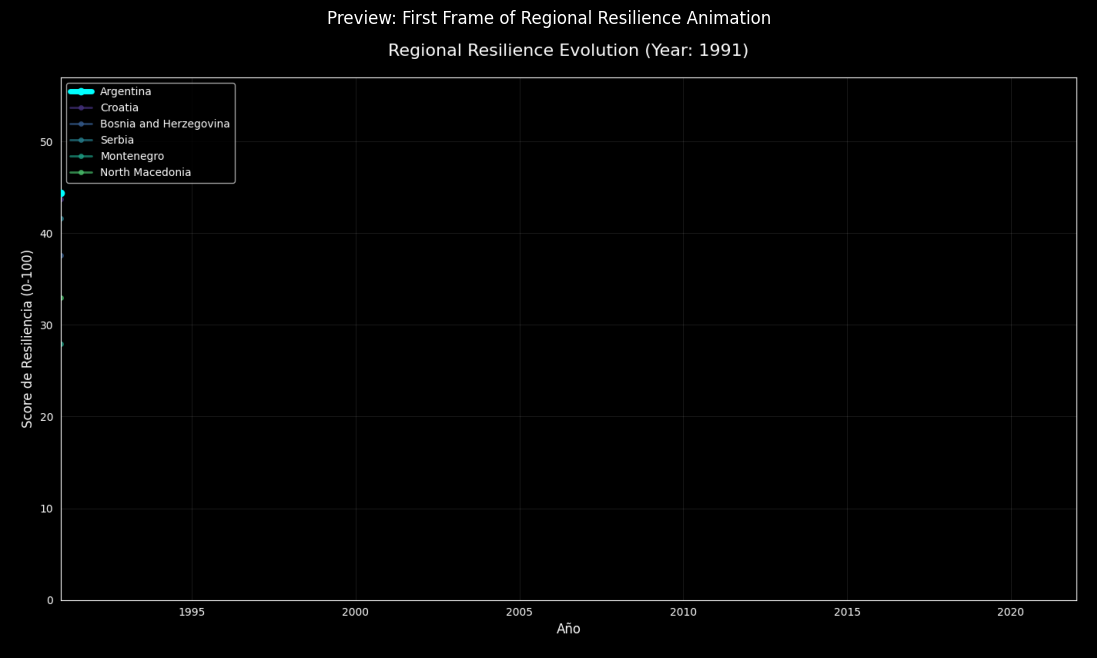

Displayed: animation_frames_regional_resilience/frame_regional_1991.png


In [66]:
import matplotlib.pyplot as plt
import os

# Define the directory where the frames are stored
frames_dir_regional_resilience = 'animation_frames_regional_resilience'

# Get a sorted list of all PNG filenames in the directory
frame_files = sorted([f for f in os.listdir(frames_dir_regional_resilience) if f.endswith('.png')])

# Check if any frames exist
if frame_files:
    # Get the path to the first frame
    first_frame_path = os.path.join(frames_dir_regional_resilience, frame_files[0])

    # Load the image
    img = plt.imread(first_frame_path)

    # Display the image
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.title('Preview: First Frame of Regional Resilience Animation')
    plt.axis('off') # Hide axes
    plt.show()
    print(f"Displayed: {first_frame_path}")
else:
    print(f"No frames found in {frames_dir_regional_resilience}")

**Reasoning**:
To display the middle frame, I need to calculate the middle index from the `frame_files` list, then load and display that specific image. This is a direct follow-up to displaying the first frame.



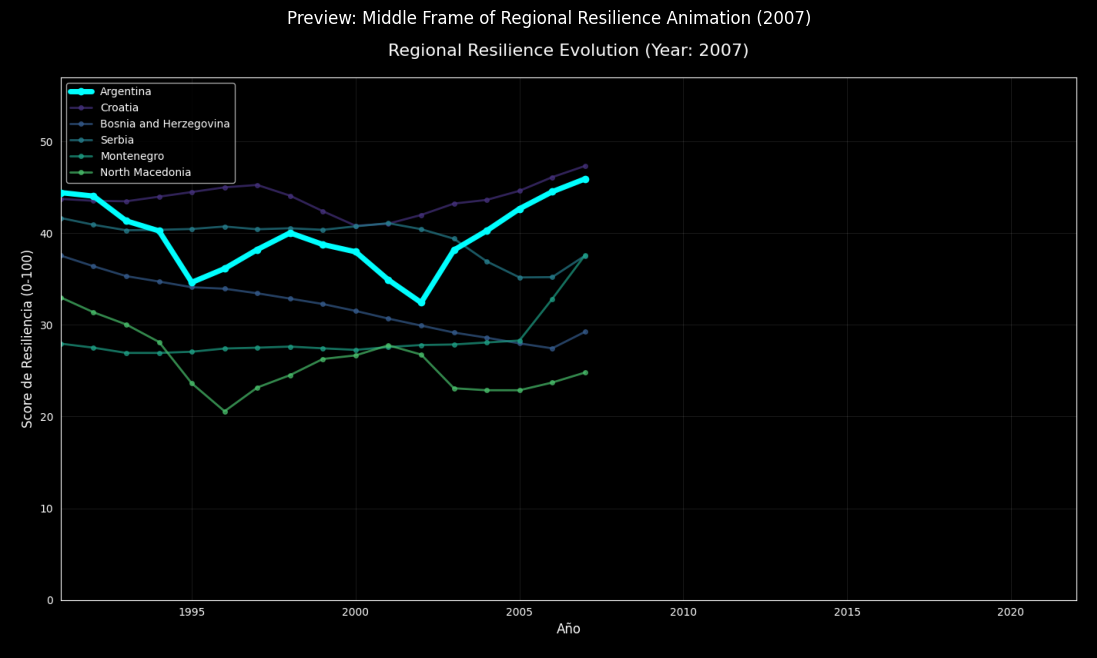

Displayed: animation_frames_regional_resilience/frame_regional_2007.png


In [67]:
import matplotlib.pyplot as plt
import os

# Define the directory where the frames are stored
frames_dir_regional_resilience = 'animation_frames_regional_resilience'

# Get a sorted list of all PNG filenames in the directory
frame_files = sorted([f for f in os.listdir(frames_dir_regional_resilience) if f.endswith('.png')])

# Check if any frames exist
if frame_files:
    # Calculate the index for the middle frame
    middle_frame_index = len(frame_files) // 2
    middle_frame_path = os.path.join(frames_dir_regional_resilience, frame_files[middle_frame_index])

    # Load the image
    img = plt.imread(middle_frame_path)

    # Display the image
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.title(f'Preview: Middle Frame of Regional Resilience Animation ({frame_files[middle_frame_index].split("_")[-1].split(".")[0]})')
    plt.axis('off') # Hide axes
    plt.show()
    print(f"Displayed: {middle_frame_path}")
else:
    print(f"No frames found in {frames_dir_regional_resilience}")

**Reasoning**:
To display the last frame, I need to get the last element from the `frame_files` list, load it as an image, and then display it. This follows the pattern of displaying the first and middle frames.



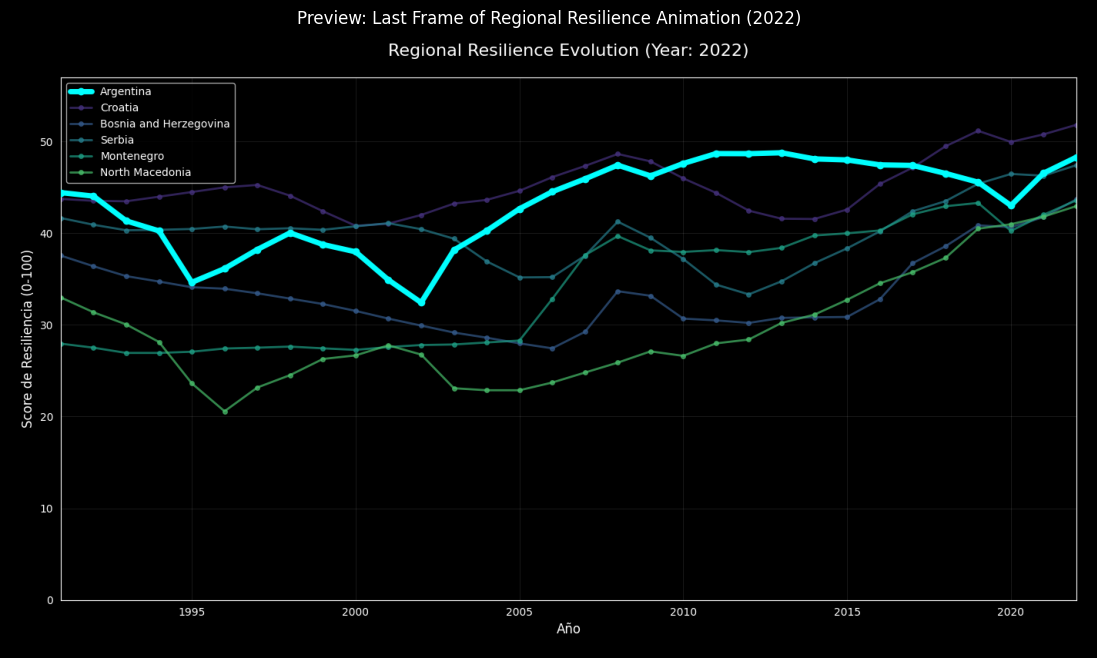

Displayed: animation_frames_regional_resilience/frame_regional_2022.png


In [68]:
import matplotlib.pyplot as plt
import os

# Define the directory where the frames are stored
frames_dir_regional_resilience = 'animation_frames_regional_resilience'

# Get a sorted list of all PNG filenames in the directory
frame_files = sorted([f for f in os.listdir(frames_dir_regional_resilience) if f.endswith('.png')])

# Check if any frames exist
if frame_files:
    # Get the path to the last frame
    last_frame_path = os.path.join(frames_dir_regional_resilience, frame_files[-1])

    # Load the image
    img = plt.imread(last_frame_path)

    # Display the image
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.title(f'Preview: Last Frame of Regional Resilience Animation ({frame_files[-1].split("_")[-1].split(".")[0]})')
    plt.axis('off') # Hide axes
    plt.show()
    print(f"Displayed: {last_frame_path}")
else:
    print(f"No frames found in {frames_dir_regional_resilience}")

# Task
Confirm the completion of the regional resilience GIF and ask the user if they would like to proceed with creating GIFs for other time-series graphs, such as specific GDP forecasts or other key indicators.

## Final Task

### Subtask:
Confirm the completion of the regional resilience GIF and ask the user if they would like to proceed with creating GIFs for other time-series graphs, such as specific GDP forecasts or other key indicators.
